# Time Series Analysis and Forecasting of Daily Mean Temperature in Delhi

**A complete beginner-to-intermediate time-series workflow: from two raw CSV files to a model comparison and a 90-day forecast with uncertainty.**

## Project Description

This project analyses **daily climate observations for Delhi, India (2013 – April 2017)** and compares **eleven forecasting models** for the **daily mean temperature (°C)**. The provided **training file** is used for exploration and model fitting, and the provided **test file** is used as the hold-out test set.

The notebook walks through the full workflow a practitioner follows: data preparation, exploratory analysis, seasonality, stationarity testing, autocorrelation analysis, chronological validation, baseline, classical and machine-learning models, residual diagnostics and a documented model-selection step before the final forecast.

| Item | Detail |
|---|---|
| **Dataset** | *Daily Climate Time Series Data* (Kaggle, `sumanthvrao/daily-climate-time-series-data`) |
| **Training file** | `DailyDelhiClimateTrain.csv` (1,462 rows × 5 columns) |
| **Test file** | `DailyDelhiClimateTest.csv` (114 rows × 5 columns) |
| **Frequency** | Daily |
| **Target** | `mean_temp` – daily mean temperature in °C |
| **Goal** | Compare models on the test file, then forecast the next 90 days with uncertainty |

**Teaching format used throughout:** *Concept → Why → Code → Result → Interpretation.*

## 2. Learning Objectives

By completing this notebook you will learn how to:

- Prepare time-series data: **datetime handling** and **time-based indexing**
- Detect **trend** and **seasonality**, and separate them with **decomposition**
- Use **rolling statistics** and **resampling** to look at the data at different scales
- Visualise time series clearly and honestly
- Explain and test **stationarity** with the **Augmented Dickey-Fuller (ADF) test**
- Apply **differencing** when it is genuinely needed
- Read **autocorrelation (ACF)** and **partial autocorrelation (PACF)** plots
- Split time-series data **chronologically** (no shuffling, no leakage)
- Build **baseline forecasts** and understand why they matter
- Fit and compare **eleven models**: baselines, moving average, ARIMA, SARIMAX with Fourier terms, harmonic regression, STL + ARIMA, Theta, and machine-learning models (Random Forest, Gradient Boosting)
- **Evaluate** forecasts with MAE, RMSE and MAPE, and analyse **residuals**
- Produce a **future forecast** with prediction intervals and communicate its limits

## Dataset Overview

| Question | Answer |
|---|---|
| **Name** | Daily Climate Time Series Data |
| **Source** | Kaggle: https://www.kaggle.com/datasets/sumanthvrao/daily-climate-time-series-data |
| **What it represents** | Daily weather observations for Delhi, India. According to the dataset page, the data was collected from the Weather Underground API. |
| **Files** | `DailyDelhiClimateTrain.csv` (1,462 rows × 5 columns) and `DailyDelhiClimateTest.csv` (114 rows × 5 columns) |
| **Columns** | `date`, `meantemp`, `humidity`, `wind_speed`, `meanpressure` |
| **Period / frequency** | Train: from 2013-01-01. Test: early 2017 (the dataset page states the data runs to 24 April 2017). One row per day. |
| **Target** | `meantemp` (renamed `mean_temp` below) |

**Why it is a good learning dataset**

- It has a clear date column and a continuous numeric target.
- Temperature has an obvious **yearly seasonal cycle**, so decomposition, ACF and seasonal models have something real to find.
- Four years of training data is enough to see the seasonal pattern repeat, yet the files are small and every step can be understood.
- It contains **abnormal values in some columns** (for example `meanpressure`), which gives a realistic data-quality check.
- Weekly seasonality is *not* expected (weather is not driven by the human work-week), which teaches you to think about which patterns make sense.

**Train/test design**

- **Training file:** used for all exploration, statistical tests, parameter selection and model fitting. The test file is **not looked at** during exploration, so no decision is influenced by it.
- **Test file:** a chronological hold-out that starts right after the training period. Every model forecasts the whole test period in one go and is scored against it.
- The test window is short (about 3.5 months, winter to early summer), which limits how much the ranking can tell us. This is discussed where the results are interpreted.

**What the final project predicts:** the daily mean temperature for the **next 90 days** after the end of the test file, with 95% prediction intervals where the model provides them.

## 3. Import Libraries

Only libraries that are actually used are imported. Plot settings are defined once so every figure is consistent.

In [4]:
import warnings
from functools import partial
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from statsmodels.tsa.forecasting.stl import STLForecast
from statsmodels.tsa.forecasting.theta import ThetaModel
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tools.sm_exceptions import ConvergenceWarning

from sklearn.base import clone
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ----- Reproducibility and global settings -----
RANDOM_SEED = 42            # no step below is random, but we fix it for safety
np.random.seed(RANDOM_SEED)

FIGSIZE = (12, 5)           # consistent figure size
ALPHA = 0.05                # significance level used for hypothesis tests
SAVE_FIGURES = True         # save figures to ../figures for the README
FIGURES_DIR = Path("../figures")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = FIGSIZE
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", message="adfuller currently returns", category=FutureWarning)

if SAVE_FIGURES:
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def finish_plot(filename=None):
    """Apply tight layout, optionally save the figure, then display it."""
    plt.tight_layout()
    if SAVE_FIGURES and filename:
        plt.savefig(FIGURES_DIR / f"{filename}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 4. Load the Datasets

**Concept:** Before any modelling we inspect the raw files: how big they are, what the columns are, whether values are missing or duplicated.

**Why:** Time-series problems often hide gaps, duplicated timestamps and sensor errors. Finding them early prevents silent mistakes later.

**Data setup:** the notebook looks for the files in `/content/` (Google Colab), then `../data/`, `data/` and the current folder.

In [5]:
TRAIN_FILE = "DailyDelhiClimateTrain.csv"
TEST_FILE = "DailyDelhiClimateTest.csv"


def find_data_file(filename):
    """Look for a dataset file in the usual locations (Colab first)."""
    candidates = [
        Path("/content") / filename,
        Path("../data") / filename,
        Path("data") / filename,
        Path(filename),
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(f"'{filename}' not found. Upload it to /content or place it in data/.")


raw_train = pd.read_csv(find_data_file(TRAIN_FILE))
raw_test = pd.read_csv(find_data_file(TEST_FILE))

print("TRAIN: first 5 rows")
display(raw_train.head())
print("TRAIN: last 5 rows")
display(raw_train.tail())
print("TEST: first 5 rows")
display(raw_test.head())
print("TEST: last 5 rows")
display(raw_test.tail())

TRAIN: first 5 rows


,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


TRAIN: last 5 rows


,date,meantemp,humidity,wind_speed,meanpressure
1457,2016-12-28,17.217391,68.043478,3.547826,1015.565217
1458,2016-12-29,15.238095,87.857143,6.000000,1016.904762
1459,2016-12-30,14.095238,89.666667,6.266667,1017.904762
1460,2016-12-31,15.052632,87.000000,7.325000,1016.100000
1461,2017-01-01,10.000000,100.000000,0.000000,1016.000000


TEST: first 5 rows


,date,meantemp,humidity,wind_speed,meanpressure
0,2017-01-01,15.913043,85.869565,2.743478,59.000000
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333


TEST: last 5 rows


,date,meantemp,humidity,wind_speed,meanpressure
109,2017-04-20,34.500,27.500000,5.562500,998.625000
110,2017-04-21,34.250,39.375000,6.962500,999.875000
111,2017-04-22,32.900,40.900000,8.890000,1001.600000
112,2017-04-23,32.875,27.500000,9.962500,1002.125000
113,2017-04-24,32.000,27.142857,12.157143,1004.142857


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
for name, raw in [("TRAIN", raw_train), ("TEST", raw_test)]:
    print("=" * 60)
    print(f"{name}: {raw.shape[0]} rows x {raw.shape[1]} columns")
    print("Column names:", list(raw.columns))
    print("\nData types")
    print(raw.dtypes)
    print("\nMissing values per column")
    print(raw.isna().sum())
    print(f"\nDuplicate rows: {raw.duplicated().sum()}")
    print("\nBasic statistics")
    display(raw.describe().T)

TRAIN: 1462 rows x 5 columns
Column names: ['date', 'meantemp', 'humidity', 'wind_speed', 'meanpressure']

Data types
date             object
meantemp        float64
humidity        float64
wind_speed      float64
meanpressure    float64
dtype: object

Missing values per column
date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

Duplicate rows: 0

Basic statistics


,count,mean,std,min,25%,50%,75%,max
meantemp,1462.0,25.495521,7.348103,6.000000,18.857143,27.714286,31.305804,38.714286
humidity,1462.0,60.771702,16.769652,13.428571,50.375000,62.625000,72.218750,100.000000
wind_speed,1462.0,6.802209,4.561602,0.000000,3.475000,6.221667,9.238235,42.220000
meanpressure,1462.0,1011.104548,180.231668,-3.041667,1001.580357,1008.563492,1014.944901,7679.333333


TEST: 114 rows x 5 columns
Column names: ['date', 'meantemp', 'humidity', 'wind_speed', 'meanpressure']

Data types
date             object
meantemp        float64
humidity        float64
wind_speed      float64
meanpressure    float64
dtype: object

Missing values per column
date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

Duplicate rows: 0

Basic statistics


,count,mean,std,min,25%,50%,75%,max
meantemp,114.0,21.713079,6.360072,11.0000,16.437198,19.875000,27.705357,34.500000
humidity,114.0,56.258362,19.068083,17.7500,39.625000,57.750000,71.902778,95.833333
wind_speed,114.0,8.143924,3.588049,1.3875,5.563542,8.069444,10.068750,19.314286
meanpressure,114.0,1004.035090,89.474692,59.0000,1007.437500,1012.739316,1016.739583,1022.809524


### Interpretation

- **Shape and head/tail** confirm that both files have the same five columns and one row per day. The training file is about thirteen times longer than the test file.
- **Data types:** `date` is read as plain text (`object`). Pandas does not treat it as a date yet, so we must convert it.
- **Missing values / duplicates:** the counts above tell us whether we need to repair anything.
- **Basic statistics:** compare the `min` and `max` of each column with what is physically plausible. Daily mean temperature should sit between a few °C and the mid-30s for Delhi. Look closely at `meanpressure`: atmospheric pressure at ground level is roughly 1000 hPa, so any minimum or maximum far from that is a red flag that we investigate in the next section.
- Compare the **ranges of the two files**: the test file covers only winter to early summer, so its temperature range is narrower than the training range.

## 5. Data Cleaning and Preparation

**Concept:** Time-series data needs a *proper time index*: unique, sorted, gap-free timestamps with a known frequency. The same cleaning rules must be applied to the training and test files.

**Why:** Almost every time-series tool (rolling windows, resampling, ACF, ARIMA) assumes ordered observations at regular intervals. A missing day or a shuffled row silently breaks lags and seasonality.

Steps performed below:

1. Rename columns to consistent `snake_case`.
2. Convert `date` to `datetime` and sort chronologically.
3. Check for duplicate dates.
4. Check for physically impossible values (flagged, not silently "fixed").
5. Check whether the two files **overlap** in time. A test row that shares a date with training data would be leakage.
6. Set `date` as the index and verify the daily frequency.
7. Handle any missing values in the **target** with a time-aware method, only if needed.

In [8]:
PLAUSIBLE_RANGES = {
    "mean_temp": (-5, 50),          # degrees Celsius
    "humidity": (0, 100),           # percent
    "wind_speed": (0, 60),          # km/h, daily mean
    "mean_pressure": (900, 1100),   # hPa, ground-level pressure
}


def prepare_climate_frame(raw, name):
    """Rename, parse dates, sort, and flag abnormal values for one file."""
    frame = raw.rename(columns={"meantemp": "mean_temp", "meanpressure": "mean_pressure"})
    frame["date"] = pd.to_datetime(frame["date"])
    frame = frame.sort_values("date").reset_index(drop=True)
    print(f"[{name}] duplicate dates: {frame['date'].duplicated().sum()}")

    for column, (lower, upper) in PLAUSIBLE_RANGES.items():
        outside_range = frame[column].notna() & ~frame[column].between(lower, upper)
        print(f"[{name}] {column:<14} allowed [{lower}, {upper}] -> {outside_range.sum()} abnormal value(s)")
        if outside_range.any():
            display(frame.loc[outside_range, ["date", column]])
            frame.loc[outside_range, column] = np.nan   # flag, do not invent replacements
    return frame.set_index("date")


train_df = prepare_climate_frame(raw_train, "train")
test_df = prepare_climate_frame(raw_test, "test")

[train] duplicate dates: 0
[train] mean_temp      allowed [-5, 50] -> 0 abnormal value(s)
[train] humidity       allowed [0, 100] -> 0 abnormal value(s)
[train] wind_speed     allowed [0, 60] -> 0 abnormal value(s)
[train] mean_pressure  allowed [900, 1100] -> 7 abnormal value(s)


,date,mean_pressure
1182,2016-03-28,7679.333333
1309,2016-08-02,310.437500
1321,2016-08-14,633.900000
1323,2016-08-16,-3.041667
1362,2016-09-24,1352.615385
1416,2016-11-17,1350.296296
1427,2016-11-28,12.045455


[test] duplicate dates: 0
[test] mean_temp      allowed [-5, 50] -> 0 abnormal value(s)
[test] humidity       allowed [0, 100] -> 0 abnormal value(s)
[test] wind_speed     allowed [0, 60] -> 0 abnormal value(s)
[test] mean_pressure  allowed [900, 1100] -> 1 abnormal value(s)


,date,mean_pressure
0,2017-01-01,59.0


### Abnormal values and overlapping dates

- Values outside the plausible range are **set to missing (`NaN`)**, because a pressure of, say, 7,000 hPa is a measurement error, not a real observation. We do **not** fill them with a made-up number. `mean_pressure` is not used by the models in this project, so no imputation is required.
- If the two files share a date, the row is removed from the **test** file. The training file is used for fitting, and the test period must begin strictly *after* it ends. Any difference between the two versions of the shared date is printed for transparency.

In [9]:
overlap_dates = train_df.index.intersection(test_df.index)
if len(overlap_dates) > 0:
    print(f"Dates present in BOTH files: {[d.date().isoformat() for d in overlap_dates]}")
    display(pd.concat(
        [train_df.loc[overlap_dates], test_df.loc[overlap_dates]], keys=["train file", "test file"]
    ))
    test_df = test_df.drop(index=overlap_dates)
    print("Overlapping rows removed from the test set.")
else:
    print("The two files do not overlap.")

gap_days = (test_df.index.min() - train_df.index.max()).days
if gap_days != 1:
    raise ValueError(f"Test data must start the day after training ends (gap = {gap_days} days).")
print(f"Test starts {gap_days} day after the training period ends: chronological order confirmed.")

Dates present in BOTH files: ['2017-01-01']


,,mean_temp,humidity,wind_speed,mean_pressure
,date,,,,
train file,2017-01-01,10.000000,100.000000,0.000000,1016.0
test file,2017-01-01,15.913043,85.869565,2.743478,NaN


Overlapping rows removed from the test set.
Test starts 1 day after the training period ends: chronological order confirmed.


In [10]:
def make_daily(frame, name):
    """Verify the daily frequency and repair isolated target gaps with time interpolation."""
    expected_dates = pd.date_range(frame.index.min(), frame.index.max(), freq="D")
    missing_dates = expected_dates.difference(frame.index)
    print(f"[{name}] {frame.index.min().date()} to {frame.index.max().date()} | "
          f"expected days: {len(expected_dates)} | missing days: {len(missing_dates)}")

    frame = frame.asfreq("D")   # makes the daily frequency explicit
    missing_target = frame["mean_temp"].isna().sum()
    if missing_target > 0:
        frame["mean_temp"] = frame["mean_temp"].interpolate(method="time")
        print(f"[{name}] interpolated {missing_target} missing target value(s).")
    else:
        print(f"[{name}] no missing target values: no imputation needed.")
    return frame


train_df = make_daily(train_df, "train")
test_df = make_daily(test_df, "test")

# `series` is the TRAINING series used for exploration (sections 6-12).
series = train_df["mean_temp"]
train = series
test = test_df["mean_temp"]

# Training + test together, used only for the final refit in section 19
full_series = pd.concat([train, test]).asfreq("D")

print(f"\nTrain: {len(train)} days | Test: {len(test)} days | Full: {len(full_series)} days")
print(f"Index frequency: {train.index.freqstr}")

[train] 2013-01-01 to 2017-01-01 | expected days: 1462 | missing days: 0
[train] no missing target values: no imputation needed.
[test] 2017-01-02 to 2017-04-24 | expected days: 113 | missing days: 0
[test] no missing target values: no imputation needed.

Train: 1462 days | Test: 113 days | Full: 1575 days
Index frequency: D


### Interpretation

- **Sorted, unique, gap-free dates** mean lag-based operations behave correctly: "one row back" always means "one day back".
- **Abnormal values were flagged, not fabricated.** Replacing a broken pressure reading with the mean would hide a data-quality problem. Time interpolation is only appropriate for the *target*, and only when isolated gaps exist, because temperature changes smoothly from day to day.
- **No leakage by construction:** the test set starts after the training period ends. Sections 6-12 use only `series` (the training data), so none of the exploration, tests or parameter choices has seen the test file.
- We now have `train` (and `series`, the same object) and `test`: daily mean temperature with a `DatetimeIndex`.

## 6. Exploratory Time Series Analysis

### 6.1 Full Time Series

**Concept:** A **line plot against time** is the first and most important time-series chart.

**Why:** It reveals trend, seasonality, unusual spikes and possible structural changes at a glance.

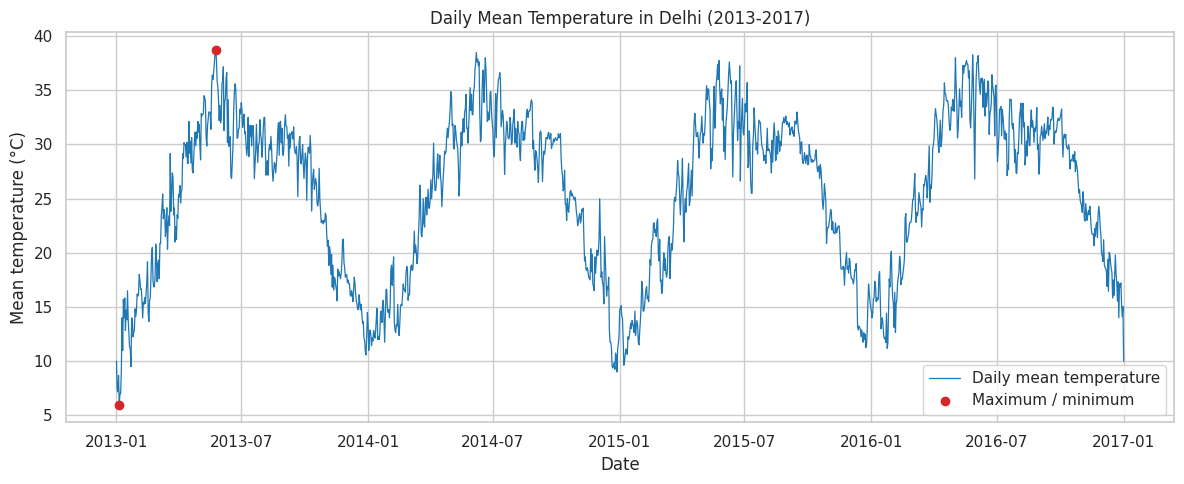

Hottest day : 2013-05-25 (38.7 °C)
Coldest day : 2013-01-05 (6.0 °C)


In [11]:
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(series.index, series, linewidth=0.9, color="tab:blue", label="Daily mean temperature")
ax.scatter(
    [series.idxmax(), series.idxmin()],
    [series.max(), series.min()],
    color="tab:red", zorder=3, label="Maximum / minimum",
)
ax.set_title("Daily Mean Temperature in Delhi (2013-2017)")
ax.set_xlabel("Date")
ax.set_ylabel("Mean temperature (°C)")
ax.legend()
finish_plot("01_full_time_series")

print(f"Hottest day : {series.idxmax().date()} ({series.max():.1f} °C)")
print(f"Coldest day : {series.idxmin().date()} ({series.min():.1f} °C)")

### Interpretation

- **Seasonality dominates.** The series rises and falls in a repeating yearly wave: hot pre-monsoon summers and cool winters.
- **Peaks and troughs** occur at roughly the same time each year, which is exactly the behaviour a seasonal model should capture.
- **Trend** is not obvious by eye over only four years. Any long-term change is small compared with the seasonal swing, so we will measure it rather than guess.
- **Structural changes** (sudden level shifts) are not visible, but with just four years we cannot rule out slower climate or measurement changes.

### 6.2 Rolling Mean

**Concept:** A **rolling (moving) mean** averages the most recent *n* observations at each point in time.

**Why:** It smooths short-term noise so longer-term movement becomes visible. The window size sets the timescale you look at. We use:

- **7 days** – removes day-to-day weather noise,
- **30 days** – approximately monthly behaviour,
- **365 days** – one full seasonal cycle, so seasonality averages out and only the **trend** remains.

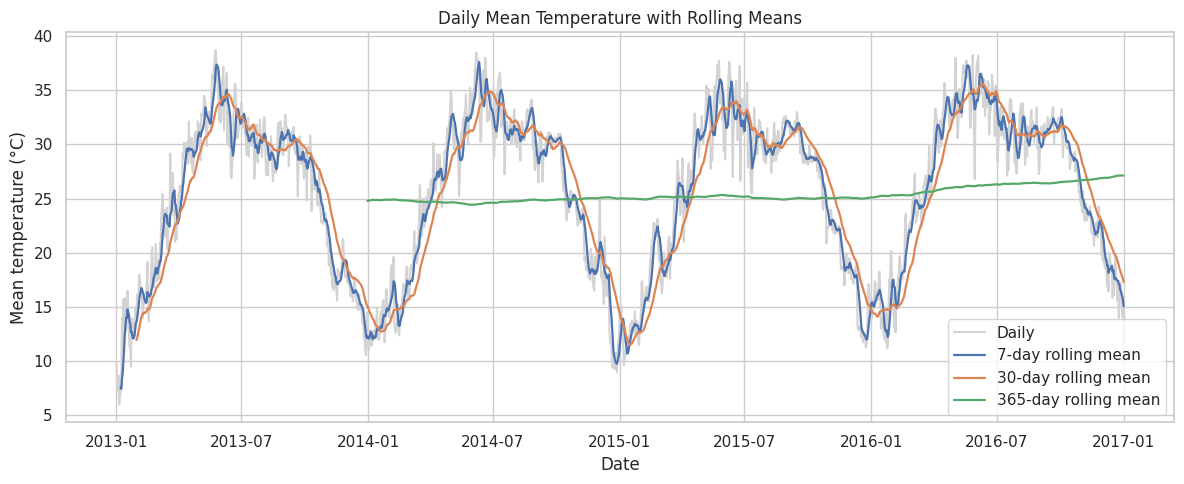

In [12]:
ROLLING_WINDOWS = [7, 30, 365]

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(series, color="lightgrey", label="Daily")
for window in ROLLING_WINDOWS:
    ax.plot(series.rolling(window=window).mean(), linewidth=1.6, label=f"{window}-day rolling mean")
ax.set_title("Daily Mean Temperature with Rolling Means")
ax.set_xlabel("Date")
ax.set_ylabel("Mean temperature (°C)")
ax.legend()
finish_plot("02_rolling_mean")

### Interpretation

- The **7-day mean** follows the seasonal wave while removing most daily jitter.
- The **30-day mean** is smoother and shows the yearly cycle clearly.
- The **365-day mean** averages over a whole seasonal cycle. Its level and slope are the best simple indicator of a long-term **trend**. It starts only after the first 365 observations, because a full window is required.

### 6.3 Rolling Standard Deviation

**Concept:** The rolling standard deviation measures how much the series varies within a recent window.

**Why:** If variability changes over time (**heteroscedasticity**), models that assume constant variance can be too confident in calm periods and too pessimistic in volatile ones.

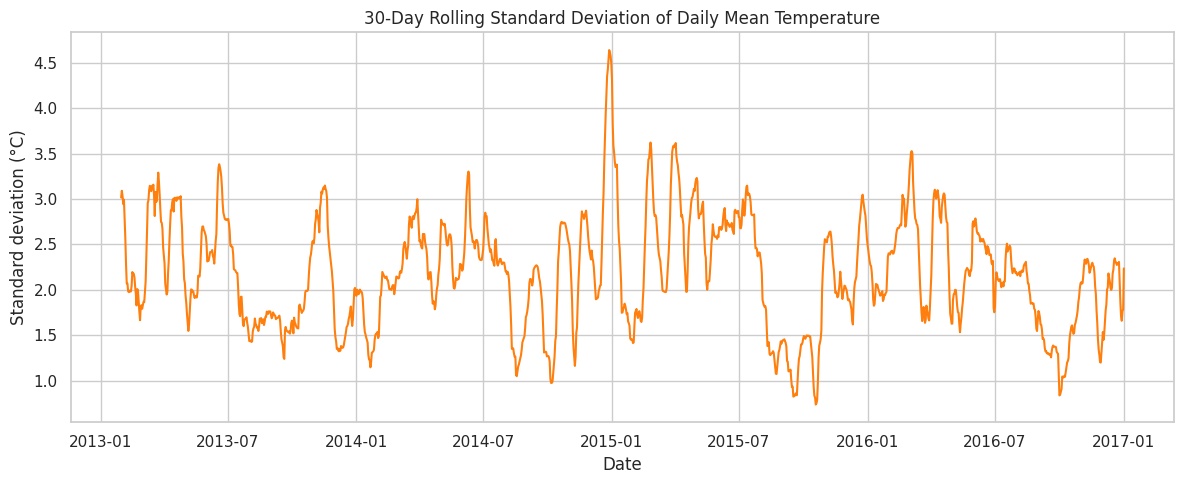

In [13]:
rolling_std_30 = series.rolling(window=30).std()

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(rolling_std_30, color="tab:orange")
ax.set_title("30-Day Rolling Standard Deviation of Daily Mean Temperature")
ax.set_xlabel("Date")
ax.set_ylabel("Standard deviation (°C)")
finish_plot("03_rolling_std")

### Interpretation

Check whether the curve stays roughly flat or rises and falls. Variability in weather data usually changes through the year (for example between the seasonal transitions and the stable stretches), and if that pattern repeats yearly it is part of the seasonal behaviour rather than evidence of a structural break. The prediction intervals produced later assume constant residual variance, which is therefore an approximation.

### 6.4 Distribution

**Concept:** A histogram (with a KDE curve) shows how the values are spread, ignoring time.

**Why:** It reveals skewness, multiple modes and outliers, and helps us judge whether an additive, roughly symmetric error model is reasonable.

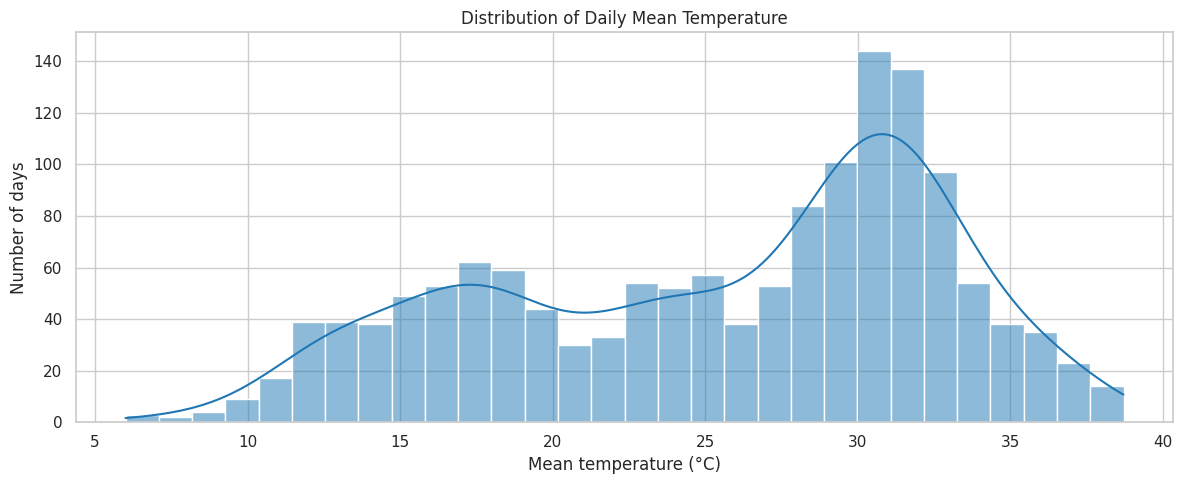

Mean: 25.50 °C | Median: 27.71 °C | Std: 7.35 °C | Skewness: -0.45


In [14]:
fig, ax = plt.subplots(figsize=FIGSIZE)
sns.histplot(series, bins=30, kde=True, color="tab:blue", ax=ax)
ax.set_title("Distribution of Daily Mean Temperature")
ax.set_xlabel("Mean temperature (°C)")
ax.set_ylabel("Number of days")
finish_plot("04_distribution")

print(f"Mean: {series.mean():.2f} °C | Median: {series.median():.2f} °C | "
      f"Std: {series.std():.2f} °C | Skewness: {series.skew():.2f}")

### Interpretation

The distribution is **wide and may show more than one bump**. Any spread of this kind is a direct consequence of seasonality: the series spends time in a cool regime and a hot regime. A single mean and standard deviation therefore describe the data poorly, which foreshadows why a "predict the average" approach will fail and why modelling the seasonal pattern matters.

## 7. Time-Based Patterns

**Concept:** Grouping observations by calendar components (month, quarter, year) shows how the target behaves at different points in the calendar.

**Why:** It turns visual impressions of seasonality into concrete numbers you can explain.

**Which patterns make sense here?** Temperature is driven by the Earth's orbit, not by the human work-week, so we expect strong **monthly/quarterly** effects and essentially **no day-of-week effect**. We still check weekday vs weekend once, as a short sanity test of that assumption.

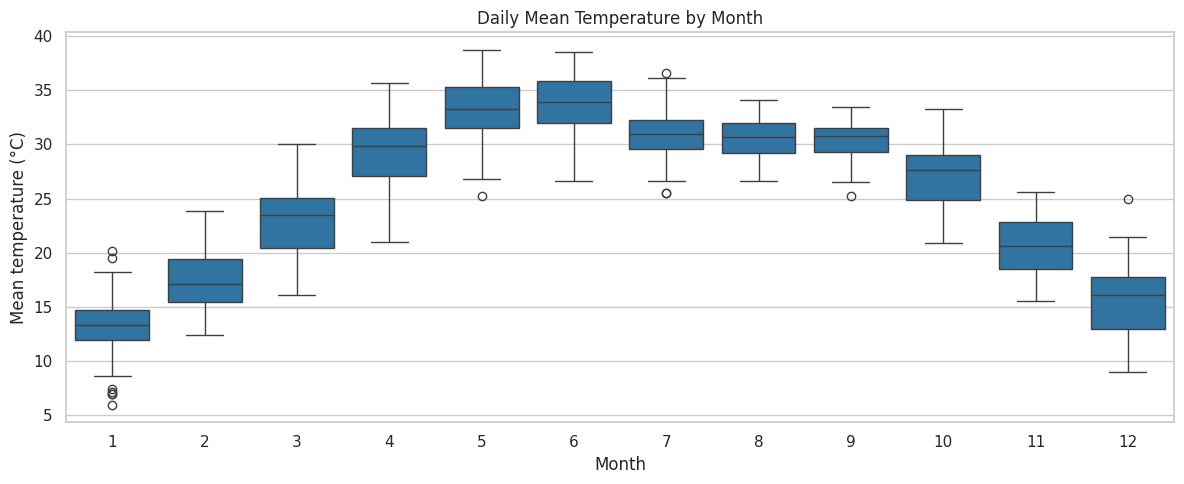

In [15]:
calendar = pd.DataFrame({"mean_temp": series})
calendar["year"] = calendar.index.year
calendar["month"] = calendar.index.month
calendar["quarter"] = calendar.index.quarter
calendar["is_weekend"] = calendar.index.dayofweek >= 5

fig, ax = plt.subplots(figsize=FIGSIZE)
sns.boxplot(data=calendar, x="month", y="mean_temp", color="tab:blue", ax=ax)
ax.set_title("Daily Mean Temperature by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Mean temperature (°C)")
finish_plot("05_temperature_by_month")

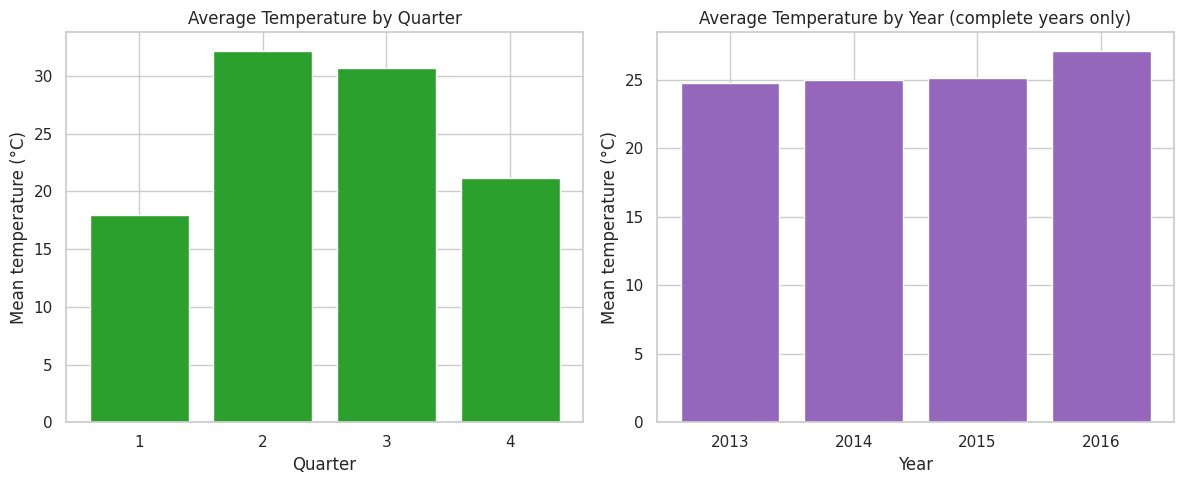

Weekday vs weekend average temperature (sanity check):
is_weekend
False    25.55
True     25.36
Name: mean_temp, dtype: float64


In [16]:
# Only use complete calendar years for yearly comparison (2017 has a single day)
days_per_year = calendar.groupby("year").size()
complete_years = days_per_year[days_per_year >= 365].index
yearly_mean = calendar[calendar["year"].isin(complete_years)].groupby("year")["mean_temp"].mean()
quarterly_mean = calendar.groupby("quarter")["mean_temp"].mean()

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
axes[0].bar(quarterly_mean.index.astype(str), quarterly_mean.values, color="tab:green")
axes[0].set_title("Average Temperature by Quarter")
axes[0].set_xlabel("Quarter")
axes[0].set_ylabel("Mean temperature (°C)")

axes[1].bar(yearly_mean.index.astype(str), yearly_mean.values, color="tab:purple")
axes[1].set_title("Average Temperature by Year (complete years only)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Mean temperature (°C)")
finish_plot("06_quarter_and_year")

print("Weekday vs weekend average temperature (sanity check):")
print(calendar.groupby("is_weekend")["mean_temp"].mean().round(2))

### Interpretation

- **Month:** the box plot shows a clear yearly cycle, with the warmest months in the pre-monsoon/summer period and the coldest in winter. The boxes within a month are fairly narrow compared with the difference *between* months, which is why the calendar month is such a strong predictor.
- **Quarter:** the same seasonal pattern at a coarser level.
- **Year:** yearly averages differ only modestly. Differences of about a degree or less between four years are not enough to claim a trend; that is why the trend was inspected with a long rolling mean and decomposition as well.
- **Weekday vs weekend:** the two averages are essentially identical, confirming that there is no weekly pattern. Adding a weekly seasonal term to a model would only add noise.

## 8. Resampling

**Concept:** **Resampling** changes the frequency of a time series, for example daily → weekly or monthly, by aggregating the observations in each new period.

**Why:** Lower frequencies reduce noise and highlight long-term structure. Different stakeholders also need different granularity (an analyst may want daily values, a report may need monthly summaries).

**When is aggregation appropriate?** The aggregation function must match the meaning of the variable:

- Temperature is an *intensity*, not an amount, so we use the **mean**. (Summing temperatures would be meaningless.)
- For quantities such as sales or rainfall we would use the **sum**.
- Incomplete periods (for example the first few days of a new month) should be excluded, otherwise they produce misleading averages.

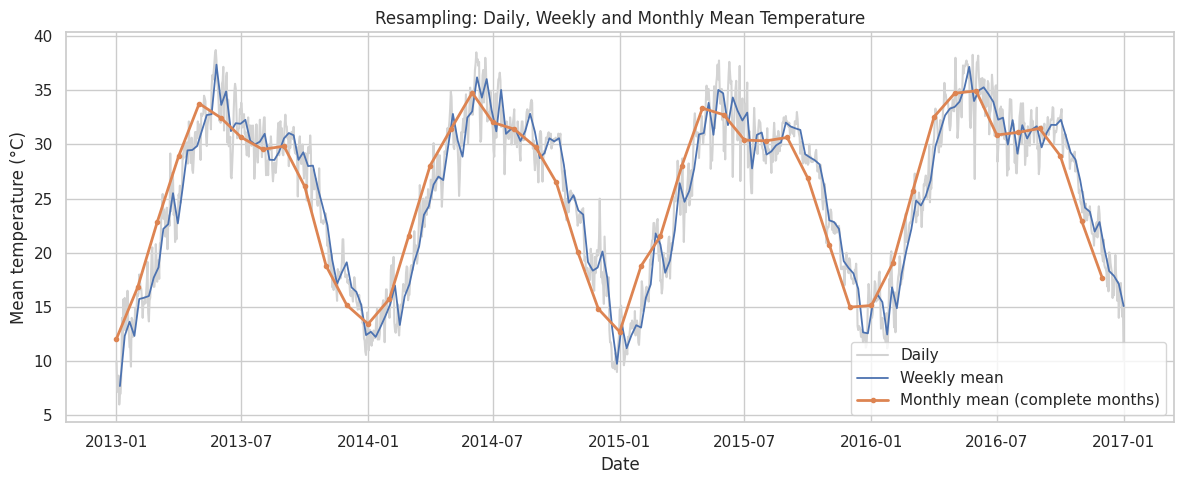

Daily observations : 1462
Weekly observations: 209
Monthly (complete) : 48


In [17]:
weekly_mean = series.resample("W").mean()
monthly_mean = series.resample("MS").mean()

# Keep only complete months for a fair monthly comparison
days_observed = series.resample("MS").count()
is_complete_month = days_observed.to_numpy() == monthly_mean.index.days_in_month.to_numpy()
monthly_complete = monthly_mean[is_complete_month]

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(series, color="lightgrey", label="Daily")
ax.plot(weekly_mean, linewidth=1.3, label="Weekly mean")
ax.plot(monthly_complete, linewidth=2, marker="o", markersize=3, label="Monthly mean (complete months)")
ax.set_title("Resampling: Daily, Weekly and Monthly Mean Temperature")
ax.set_xlabel("Date")
ax.set_ylabel("Mean temperature (°C)")
ax.legend()
finish_plot("07_resampling")

print(f"Daily observations : {len(series)}")
print(f"Weekly observations: {len(weekly_mean)}")
print(f"Monthly (complete) : {len(monthly_complete)}")

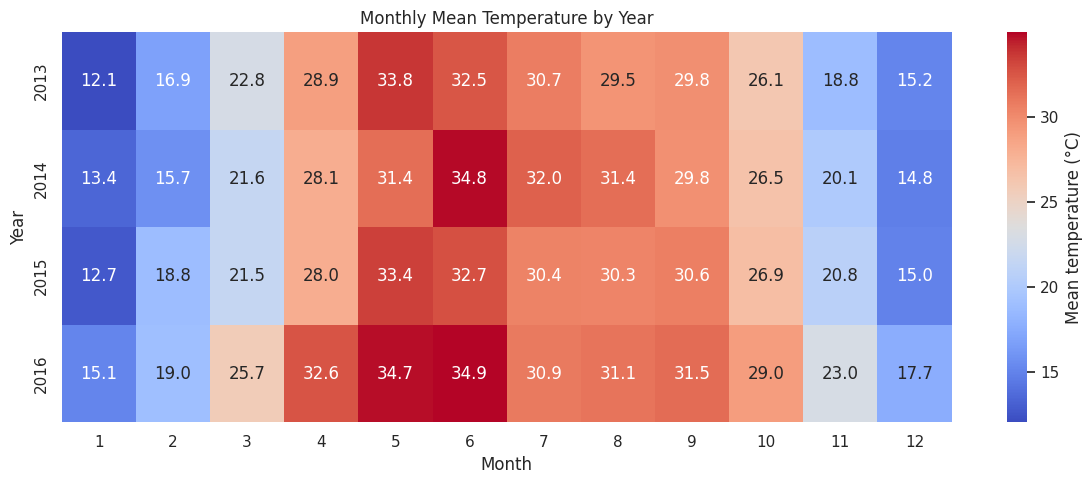

In [18]:
heatmap_data = monthly_complete.to_frame("mean_temp")
heatmap_data["year"] = heatmap_data.index.year
heatmap_data["month"] = heatmap_data.index.month
monthly_pivot = heatmap_data.pivot(index="year", columns="month", values="mean_temp")

fig, ax = plt.subplots(figsize=FIGSIZE)
sns.heatmap(monthly_pivot, annot=True, fmt=".1f", cmap="coolwarm",
            cbar_kws={"label": "Mean temperature (°C)"}, ax=ax)
ax.set_title("Monthly Mean Temperature by Year")
ax.set_xlabel("Month")
ax.set_ylabel("Year")
finish_plot("08_monthly_heatmap")

# Average monthly profile (climatology), used again in the key findings
monthly_climatology = monthly_complete.groupby(monthly_complete.index.month).mean()

### Interpretation

- Weekly and monthly means remove daily weather noise and make the seasonal wave much cleaner. The monthly series has only about 48 points, which is too short to fit a seasonal model reliably, so **we keep the daily series for modelling** and use resampling for understanding.
- The heatmap shows that each **column (month)** has a consistent colour across years while colours change strongly **across months**. This is seasonality in its most compact form: the same month is similar every year, and the difference between years is small.

## 9. Decomposition

**Concept:** Decomposition splits a series into components:

- **Trend** – the slow long-term direction,
- **Seasonal** – a pattern that repeats every fixed period,
- **Residual** – what is left over (irregular, unexplained variation).

An **additive** model assumes `observed = trend + seasonal + residual`. We choose additive because the size of the seasonal swing (in °C) does not grow as the level rises. A multiplicative model would be preferred if the swing scaled with the level.

**Seasonal period:** the data is daily and the dominant cycle is yearly, so `period = 365`. (A leap year adds one day; the effect on the decomposition is negligible.) `seasonal_decompose` needs at least two full periods (730 days); we have about four years.

**Why:** Decomposition tells us *how much* of the variation is predictable seasonality, and it guides model choice.

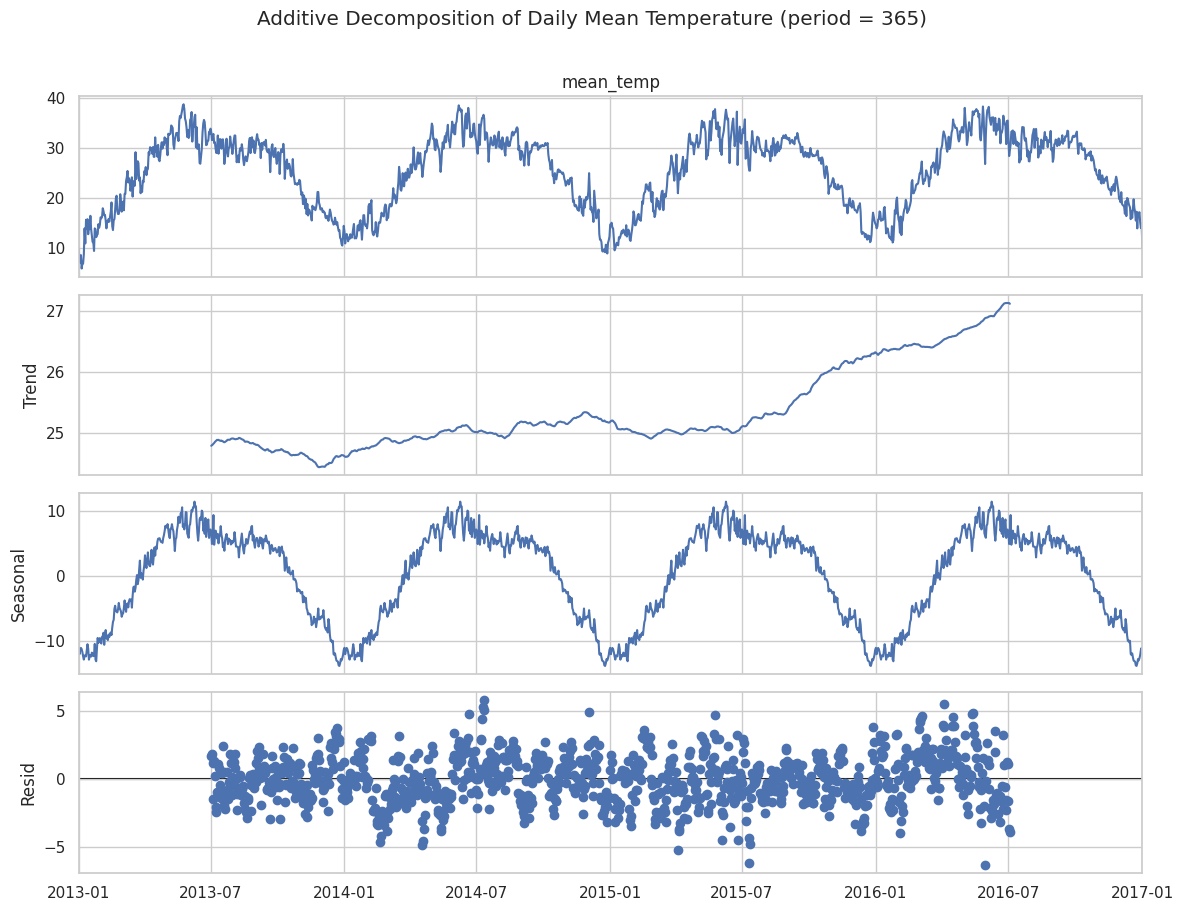

Seasonal strength: 0.94
Trend strength   : 0.17


In [19]:
SEASONAL_PERIOD = 365

decomposition = seasonal_decompose(series, model="additive", period=SEASONAL_PERIOD)

fig = decomposition.plot()
fig.set_size_inches(12, 9)
fig.suptitle("Additive Decomposition of Daily Mean Temperature (period = 365)", y=1.01)
finish_plot("09_decomposition")

# Strength of seasonality / trend (0 = none, 1 = very strong), after Hyndman & Athanasopoulos
residual = decomposition.resid.dropna()
seasonal_part = decomposition.seasonal.loc[residual.index]
trend_part = decomposition.trend.loc[residual.index]

seasonal_strength = max(0.0, 1 - residual.var() / (residual + seasonal_part).var())
trend_strength = max(0.0, 1 - residual.var() / (residual + trend_part).var())
print(f"Seasonal strength: {seasonal_strength:.2f}")
print(f"Trend strength   : {trend_strength:.2f}")

### Interpretation

- **Observed:** the original data.
- **Trend:** a smooth curve. Note that it is missing at both ends because the centred moving average needs half a period on each side.
- **Seasonal:** one yearly shape repeated exactly. The size of this component shows how large the seasonal swing is.
- **Residual:** what remains after removing trend and seasonality: the day-to-day weather variation the model cannot explain with the calendar alone.
- **Strength scores:** a seasonal strength close to 1 means most of the variation is explained by the repeating yearly pattern; a trend strength much lower means the long-term direction is minor in comparison. This supports using a **seasonal component** in the final model.

## 10. Stationarity

**Concept:** A time series is **(weakly) stationary** if its statistical properties do not depend on *when* you look: constant mean, constant variance, and autocorrelation that depends only on the lag between observations.

**Why it matters:** ARIMA-type models are built for stationary data (after differencing). A series with trend or seasonality has a mean that changes over time, so past patterns do not carry over in a stable way.

### The Augmented Dickey-Fuller (ADF) test

- **Null hypothesis (H0):** the series has a **unit root**, meaning it is **non-stationary**.
- **Alternative hypothesis (H1):** the series has no unit root, meaning it is **stationary**.
- **p-value:** the probability of seeing a test statistic at least this extreme *if H0 were true*.
  - `p < 0.05` → reject H0 → evidence of stationarity.
  - `p ≥ 0.05` → fail to reject H0 → we cannot conclude the series is stationary.
- **Test statistic vs critical values:** the statistic must be *more negative* than the critical value to reject H0.

> **Caveat:** ADF tests for a *stochastic* trend (unit root). It has limited power against strong **deterministic seasonality**, so we combine it with plots and ACF, never rely on it alone. Also, "failing to reject" is not proof of non-stationarity.

In [20]:
def run_adf_test(data, label):
    """Run the ADF test, print a readable report and return the p-value."""
    statistic, p_value, used_lags, n_obs, critical_values, _ = adfuller(data.dropna(), autolag="AIC")

    print(f"ADF test: {label}")
    print(f"  ADF statistic : {statistic:.4f}")
    print(f"  p-value       : {p_value:.4f}")
    print(f"  Lags used     : {used_lags}")
    print(f"  Observations  : {n_obs}")
    print("  Critical values:")
    for level, value in critical_values.items():
        print(f"    {level:>3}: {value:.4f}")

    if p_value < ALPHA:
        print(f"  -> p < {ALPHA}: reject H0. Evidence that the series is STATIONARY.\n")
    else:
        print(f"  -> p >= {ALPHA}: fail to reject H0. The series is treated as NON-STATIONARY.\n")
    return p_value


adf_p_original = run_adf_test(series, "daily mean temperature (original)")

ADF test: daily mean temperature (original)
  ADF statistic : -2.0211
  p-value       : 0.2774
  Lags used     : 10
  Observations  : 1451
  Critical values:
     1%: -3.4349
     5%: -2.8635
    10%: -2.5678
  -> p >= 0.05: fail to reject H0. The series is treated as NON-STATIONARY.



### Interpretation

Read the report in three steps: (1) compare the **ADF statistic** with the 5% critical value, (2) check the **p-value** against 0.05, (3) read the printed conclusion.

Even if the test rejects the unit root, the series is **not stationary in the strict sense**: its mean clearly follows a yearly cycle (see the decomposition). The test is telling us there is no *random-walk-like* drift, while the *deterministic seasonality* still has to be handled by the model (seasonal terms or seasonal regressors). This is why the later sections compare a plain ARIMA with a model that includes explicit seasonal terms.

## 11. Differencing

**Concept:** **First-order differencing** replaces each value with its change from the previous one: `y'(t) = y(t) - y(t-1)`.

**Why:** It removes a stochastic trend / unit root, turning a wandering series into a stable one. But differencing is not free: **over-differencing** adds noise and destroys information. We therefore difference only if it is justified, and we test the result.

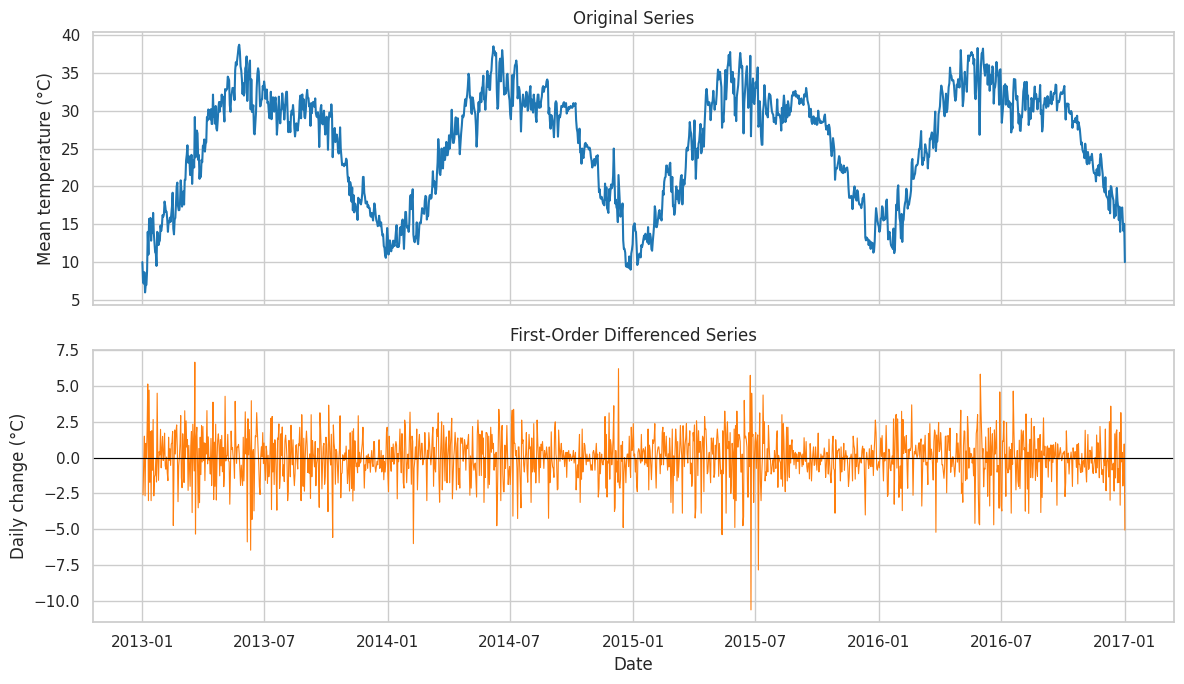

ADF test: first-order differenced series
  ADF statistic : -16.3787
  p-value       : 0.0000
  Lags used     : 9
  Observations  : 1451
  Critical values:
     1%: -3.4349
     5%: -2.8635
    10%: -2.5678
  -> p < 0.05: reject H0. Evidence that the series is STATIONARY.

Differencing order chosen for ARIMA: d = 1


In [21]:
series_diff = series.diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(series, color="tab:blue")
axes[0].set_title("Original Series")
axes[0].set_ylabel("Mean temperature (°C)")
axes[1].plot(series_diff, color="tab:orange", linewidth=0.8)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("First-Order Differenced Series")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Daily change (°C)")
finish_plot("10_differencing")

adf_p_diff = run_adf_test(series_diff, "first-order differenced series")

# Differencing order used for the plain ARIMA model: only if the original fails the ADF test
d_order = 0 if adf_p_original < ALPHA else 1
print(f"Differencing order chosen for ARIMA: d = {d_order}")

### Interpretation

- The differenced series fluctuates around **zero** with no visible seasonal wave: the slow seasonal movement has been removed and only daily changes remain. Its ADF test is typically strongly stationary.
- The differencing order `d` for ARIMA is set by a **rule stated in advance** (difference only when the original series fails the ADF test), not chosen after looking at model scores.
- Note that differencing at lag 1 does **not** remove a 365-day seasonal pattern; it only removes the slowly moving level. Seasonality needs its own treatment, which is why we add seasonal terms later.

## 12. ACF and PACF

**Concept**

- **Lag:** a time shift. Lag 1 compares each day with the previous day; lag 7 with a week earlier.
- **Autocorrelation (ACF):** the correlation between the series and its own lagged copy, *including* indirect effects passed through intermediate lags.
- **Partial autocorrelation (PACF):** the correlation at lag *k* after **removing** the influence of lags 1…*k*-1, so it shows the *direct* effect of lag *k*.

**Why:** ACF/PACF patterns suggest the structure of ARIMA models.

| Pattern | Suggests |
|---|---|
| PACF cuts off after lag *p*, ACF decays slowly | AR(*p*) |
| ACF cuts off after lag *q*, PACF decays slowly | MA(*q*) |
| Both decay slowly | mixed ARMA, or the series needs differencing |
| ACF with repeated waves at a fixed lag | seasonality at that lag |

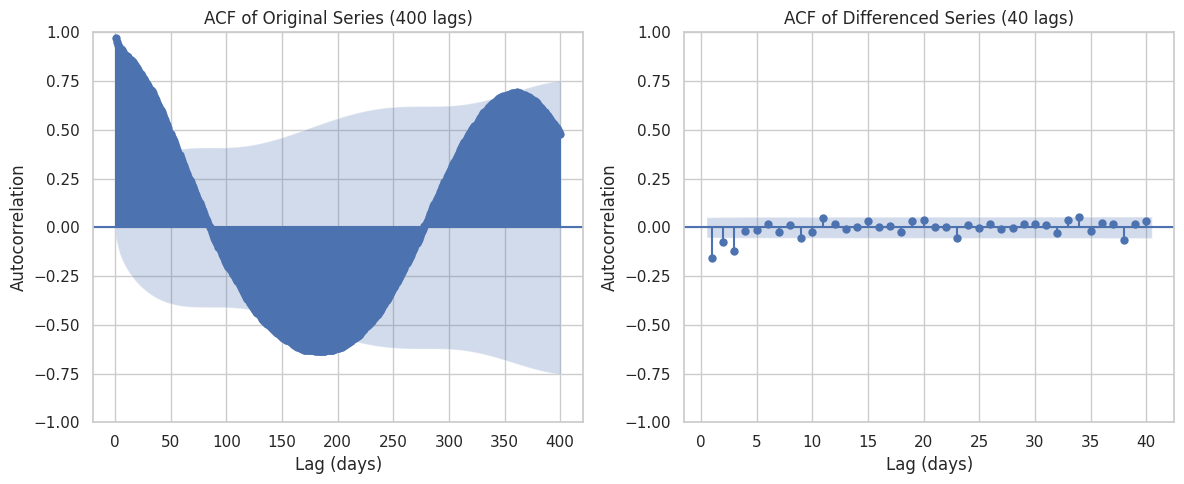

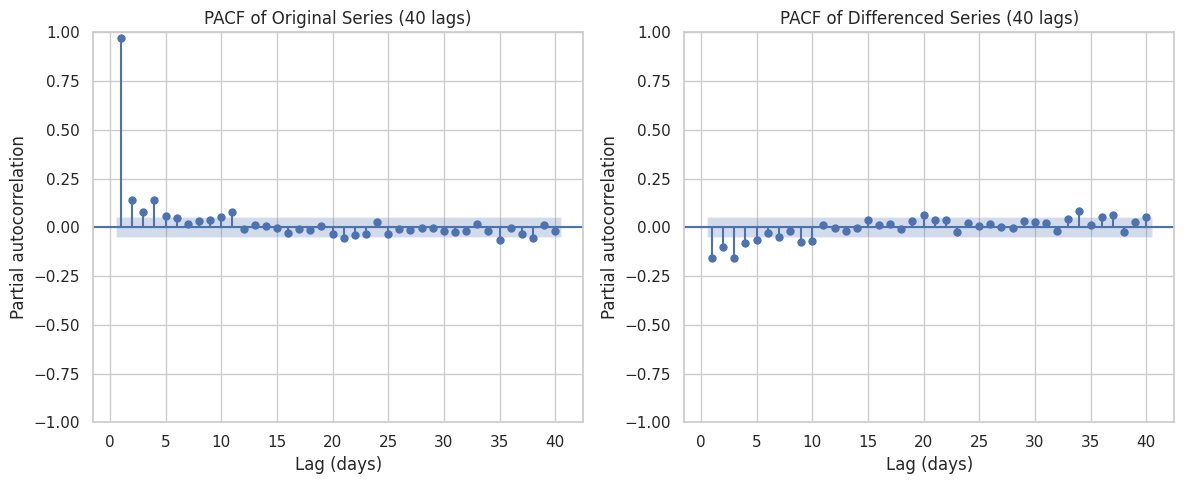

In [22]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
plot_acf(series, lags=400, ax=axes[0], zero=False)
axes[0].set_title("ACF of Original Series (400 lags)")
axes[0].set_xlabel("Lag (days)")
axes[0].set_ylabel("Autocorrelation")

plot_acf(series_diff, lags=40, ax=axes[1], zero=False)
axes[1].set_title("ACF of Differenced Series (40 lags)")
axes[1].set_xlabel("Lag (days)")
axes[1].set_ylabel("Autocorrelation")
finish_plot("11_acf")

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
plot_pacf(series, lags=40, ax=axes[0], zero=False, method="ywm")
axes[0].set_title("PACF of Original Series (40 lags)")
axes[0].set_xlabel("Lag (days)")
axes[0].set_ylabel("Partial autocorrelation")

plot_pacf(series_diff, lags=40, ax=axes[1], zero=False, method="ywm")
axes[1].set_title("PACF of Differenced Series (40 lags)")
axes[1].set_xlabel("Lag (days)")
axes[1].set_ylabel("Partial autocorrelation")
finish_plot("12_pacf")

### Interpretation

- **ACF of the original series:** the correlations start very high and decay slowly, then swing negative and return positive around lag ≈ 365. This wave is the signature of **yearly seasonality**: today's temperature resembles the temperature one year ago.
- **PACF of the original series:** a large spike at lag 1 and small values afterwards suggests that most of the *direct* dependence is on yesterday's value (an AR(1)-like behaviour).
- **Differenced series:** the correlation structure is much weaker, so a small ARMA structure on top is enough. Shaded bands are approximate 95% confidence limits: spikes outside them are statistically meaningful.
- We therefore keep the ARIMA search **small** (orders up to 2) and choose the final order by **AIC on the training data only**, a criterion that rewards fit but penalises unnecessary complexity. This is far more defensible than testing hundreds of combinations.

## 13. Train/Test Split

**Concept:** The data is already split into two files that follow each other in time. `DailyDelhiClimateTrain.csv` is the **past** and `DailyDelhiClimateTest.csv` is the **future** that we try to forecast.

**Why a chronological split?** Forecasting means predicting the *future* from the *past*. A random split would put future days into the training set and past days into the test set, so the model could "peek" at tomorrow to predict yesterday. The result would look excellent but would be **data leakage** and would not reflect real performance. Neighbouring days are also strongly correlated, so random splitting makes the test set almost a copy of the training set. Here the split is chronological by construction, and section 5 verified that the test file starts right after the training period.

Train: 2013-01-01 to 2017-01-01 (1462 days)
Test : 2017-01-02 to 2017-04-24 (113 days)


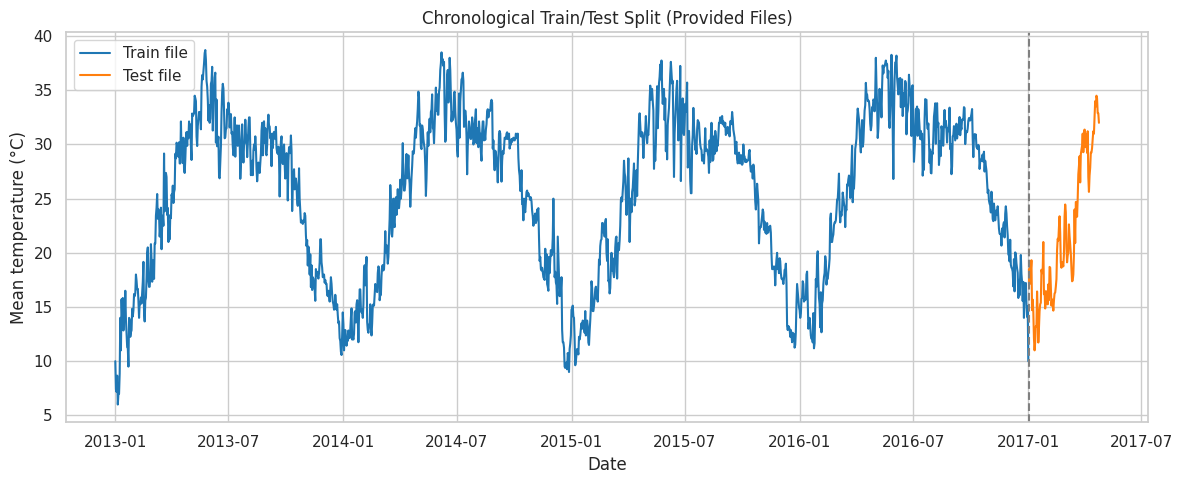

In [23]:
print(f"Train: {train.index.min().date()} to {train.index.max().date()} ({len(train)} days)")
print(f"Test : {test.index.min().date()} to {test.index.max().date()} ({len(test)} days)")

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(train, label="Train file", color="tab:blue")
ax.plot(test, label="Test file", color="tab:orange")
ax.axvline(test.index[0], color="grey", linestyle="--")
ax.set_title("Chronological Train/Test Split (Provided Files)")
ax.set_xlabel("Date")
ax.set_ylabel("Mean temperature (°C)")
ax.legend()
finish_plot("13_train_test_split")

### Interpretation

- The dashed line separates the **past (train)** from the **future (test)**. All model fitting, parameter selection and AIC comparison below use **only the training data**.
- The test period is about **3.5 months** long and covers the **winter-to-early-summer** part of the seasonal cycle. Each model must forecast all of it in one go, up to roughly 113 days ahead, not just tomorrow.
- **Limitation to remember:** the test window does not contain the monsoon or the hottest months. A model's ranking here is evidence about forecasting the January-April period, and should not be treated as proof about the whole year.

## 14. Baseline Models and Evaluation Metrics

**Concept:** A **baseline** is the simplest sensible forecast. We use simple rules:

1. **Naive:** every future value equals the **last observed training value**.
2. **Seasonal naive:** every future value equals the value **one year (365 days) earlier**.
3. **Seasonal mean:** every future value equals the **average of the same date in all previous years**.

**Why:** A baseline tells you how hard the problem is. A sophisticated model is only worthwhile if it beats these simple rules.

All models below are evaluated in the **same way**: they see only the training data and produce a **multi-step forecast for the whole test period at once**. Nothing from the test set is used to make its own forecast.

### Evaluation metrics

- **MAE** – average absolute error in °C. Easy to interpret.
- **RMSE** – square root of the mean squared error, in °C. Penalises large errors more than MAE.
- **MAPE** – mean absolute percentage error. Use with care: the Celsius scale has an arbitrary zero, so percentage errors are not fully meaningful and inflate when temperatures are low. It is reported for completeness only.

In [24]:
def evaluate_forecast(actual, predicted):
    """Return MAE, RMSE and MAPE (%) for aligned actual and predicted values."""
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    non_zero = actual != 0
    mape = np.mean(np.abs((actual[non_zero] - predicted[non_zero]) / actual[non_zero])) * 100
    return {"MAE": float(mae), "RMSE": float(rmse), "MAPE (%)": float(mape)}


def forecast_naive(history, index):
    """Repeat the last observed value."""
    return pd.DataFrame({"forecast": history.iloc[-1]}, index=index)


def forecast_seasonal_naive(history, index, period_days=SEASONAL_PERIOD):
    """Use the value observed one seasonal period earlier."""
    lookup_dates = index - pd.Timedelta(days=period_days)
    values = history.reindex(lookup_dates).to_numpy()
    if np.isnan(values).any():
        raise ValueError("Forecast horizon is longer than the seasonal period allows.")
    return pd.DataFrame({"forecast": values}, index=index)


def forecast_seasonal_mean(history, index, period_days=SEASONAL_PERIOD, max_cycles=4):
    """Average the values observed 1, 2, ... `max_cycles` seasonal periods earlier."""
    lookups = [
        history.reindex(index - pd.Timedelta(days=period_days * cycle)).to_numpy()
        for cycle in range(1, max_cycles + 1)
    ]
    values = np.vstack(lookups)
    if np.isnan(values).all(axis=0).any():
        raise ValueError("Some forecast dates have no earlier seasonal observation.")
    return pd.DataFrame({"forecast": np.nanmean(values, axis=0)}, index=index)


def forecast_moving_average(history, index, window=30):
    """Repeat the mean of the last `window` observations."""
    return pd.DataFrame({"forecast": history.iloc[-window:].mean()}, index=index)


naive_scores = evaluate_forecast(test, forecast_naive(train, test.index)["forecast"])
print("Naive baseline:", {name: round(value, 3) for name, value in naive_scores.items()})

Naive baseline: {'MAE': 11.764, 'RMSE': 13.362, 'MAPE (%)': 50.027}


### Interpretation

The naive forecast is a **flat line** at the last training value. It ignores the season entirely, so it is only correct when the real temperature happens to pass through that level. The seasonal baselines use last year's (or the average of all previous years') values for the same dates, so they already know the seasonal shape. Their errors set the bar that the more complex models must clear.

## 15. Forecasting Models

We compare **eleven models**, each fitted on the training set only.

| # | Model | Family | Idea |
|---|---|---|---|
| 1 | **Naive** | baseline | last value repeated |
| 2 | **Seasonal Naive (365d)** | baseline | value from the same day one year earlier |
| 3 | **Seasonal Mean** | baseline | average of the same date in all earlier years |
| 4 | **Moving Average (30d)** | smoothing | mean of the last 30 days repeated |
| 5 | **ARIMA** | classical | AutoRegressive Integrated Moving Average, no seasonal terms |
| 6 | **Harmonic Regression** | regression | linear trend + sine/cosine seasonal terms |
| 7 | **SARIMAX + Fourier** | classical | sine/cosine seasonal regressors with ARIMA errors |
| 8 | **STL + ARIMA** | decomposition | remove seasonality with STL, forecast the rest with ARIMA, add seasonality back |
| 9 | **Theta** | classical | seasonally adjusted Theta method (additive seasonality) |
| 10 | **Random Forest (lags)** | machine learning | trees on recent lags + seasonal terms, forecast recursively |
| 11 | **Gradient Boosting (lags)** | machine learning | boosted trees on the same features, forecast recursively |

### Why not a classic SARIMA with a 365-day season?

`SARIMA(p,d,q)(P,D,Q)[365]` on daily data creates a state space with hundreds of hidden states: it is extremely slow, numerically unstable and needs many years of data. The standard, practical alternatives are the **Fourier-term regression (SARIMAX)** and **STL + ARIMA** used here.

### How the parameters are chosen (explainable and small)

- **ARIMA `d`** is set by the ADF rule from section 11. `p` and `q` are searched only over 0-2 (9 candidates) and the lowest **AIC on the training data** wins.
- **Fourier models:** the number of harmonics `K` (1-3) is compared by AIC, with `d = 0` because the seasonal regressors already handle the cycle.
- **STL + ARIMA:** the ARIMA order is chosen by AIC on the STL-seasonally-adjusted training series.
- **Machine-learning models:** fixed, moderate hyperparameters, no tuning. This is deliberate: tuning on the short test window would leak test information, and a fair tuning procedure would need its own validation split.

> **Note:** AIC is only comparable between models fitted to the *same* response series with the *same* `d`. We compare `(p, q)` and `K` within a model family, never one family against another. Families are compared on the test set.

In [25]:
def make_fourier_terms(index, origin, period=365.25, n_harmonics=2):
    """Build sine/cosine columns that represent a smooth yearly cycle.

    `origin` is a fixed reference date so training and future dates share
    exactly the same time scale.
    """
    days_since_origin = (index - origin).days.to_numpy()
    terms = {}
    for k in range(1, n_harmonics + 1):
        angle = 2 * np.pi * k * days_since_origin / period
        terms[f"sin_{k}"] = np.sin(angle)
        terms[f"cos_{k}"] = np.cos(angle)
    return pd.DataFrame(terms, index=index)


def select_order_by_aic(history, d, exog=None, max_p=2, max_q=2):
    """Fit a small grid of (p, d, q) models and rank them by AIC."""
    trend = "c" if d == 0 else "n"   # a constant is only meaningful without differencing
    records = []
    for p in range(max_p + 1):
        for q in range(max_q + 1):
            try:
                fitted = SARIMAX(history, exog=exog, order=(p, d, q), trend=trend).fit(disp=False)
            except (ValueError, np.linalg.LinAlgError):
                continue
            records.append({"order": (p, d, q), "AIC": fitted.aic})
    return pd.DataFrame(records).sort_values("AIC").reset_index(drop=True)


FOURIER_ORIGIN = train.index[0]

### Model 5: ARIMA (no seasonality)

In [26]:
arima_search = select_order_by_aic(train, d=d_order)
display(arima_search)

arima_order = arima_search.loc[0, "order"]
print(f"Selected ARIMA order (lowest AIC on training data): {arima_order}")

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


,order,AIC
0,"(1, 1, 1)",5542.478219
1,"(2, 1, 1)",5544.118415
2,"(1, 1, 2)",5544.186181
3,"(2, 1, 2)",5544.332281
4,"(0, 1, 2)",5571.729326
5,"(2, 1, 0)",5598.850425
6,"(0, 1, 1)",5600.114918
7,"(1, 1, 0)",5612.068380
8,"(0, 1, 0)",5648.181489


Selected ARIMA order (lowest AIC on training data): (1, 1, 1)


### Models 6 and 7: Fourier-based models

Choosing the number of harmonics `K` (with `d = 0`) on the training set:

In [27]:
fourier_search_rows = []
for n_harmonics in (1, 2, 3):
    exog_train = make_fourier_terms(train.index, FOURIER_ORIGIN, n_harmonics=n_harmonics)
    best_row = select_order_by_aic(train, d=0, exog=exog_train).loc[0]
    fourier_search_rows.append(
        {"harmonics (K)": n_harmonics, "best order": best_row["order"], "AIC": best_row["AIC"]}
    )

fourier_search = pd.DataFrame(fourier_search_rows).sort_values("AIC").reset_index(drop=True)
display(fourier_search)

n_harmonics_selected = int(fourier_search.loc[0, "harmonics (K)"])
sarimax_order = fourier_search.loc[0, "best order"]
print(f"Selected: K = {n_harmonics_selected} harmonics, ARIMA errors of order {sarimax_order}")

,harmonics (K),best order,AIC
0,3,"(1, 0, 1)",5453.564184
1,2,"(1, 0, 1)",5456.827532
2,1,"(2, 0, 1)",5495.301770


Selected: K = 3 harmonics, ARIMA errors of order (1, 0, 1)


### Model 8: STL + ARIMA

STL (Seasonal-Trend decomposition using LOESS) removes the yearly pattern. The ARIMA order is chosen on the seasonally adjusted **training** series.

In [28]:
stl_result = STL(train, period=SEASONAL_PERIOD).fit()
seasonally_adjusted = train - stl_result.seasonal

stl_search = select_order_by_aic(seasonally_adjusted, d=0)
display(stl_search)

stl_order = stl_search.loc[0, "order"]
print(f"Selected ARIMA order for the seasonally adjusted series: {stl_order}")

,order,AIC
0,"(2, 0, 2)",4079.971461
1,"(2, 0, 1)",4086.998843
2,"(1, 0, 0)",4090.783509
3,"(1, 0, 2)",4091.129067
4,"(1, 0, 1)",4091.221500
5,"(2, 0, 0)",4091.317919
6,"(0, 0, 2)",4409.426406
7,"(0, 0, 1)",4812.817545
8,"(0, 0, 0)",5704.496277


Selected ARIMA order for the seasonally adjusted series: (2, 0, 2)


In [29]:
def _forecast_with_intervals(fitted_model, index, exog=None, alpha=ALPHA):
    """Return point forecasts and prediction intervals as a DataFrame."""
    prediction = fitted_model.get_forecast(steps=len(index), exog=exog)
    intervals = prediction.conf_int(alpha=alpha)
    return pd.DataFrame(
        {
            "forecast": prediction.predicted_mean.to_numpy(),
            "lower": intervals.iloc[:, 0].to_numpy(),
            "upper": intervals.iloc[:, 1].to_numpy(),
        },
        index=index,
    )


def forecast_arima(history, index, order):
    """Fit ARIMA on `history` and forecast the dates in `index`."""
    fitted = ARIMA(history, order=order).fit()
    return _forecast_with_intervals(fitted, index)


def forecast_sarimax_fourier(history, index, order, n_harmonics, origin=FOURIER_ORIGIN):
    """Fit ARIMA errors + Fourier regressors on `history` and forecast `index`."""
    exog_history = make_fourier_terms(history.index, origin, n_harmonics=n_harmonics)
    exog_future = make_fourier_terms(index, origin, n_harmonics=n_harmonics)
    fitted = SARIMAX(history, exog=exog_history, order=order, trend="c").fit(disp=False)
    return _forecast_with_intervals(fitted, index, exog=exog_future)


def forecast_harmonic_regression(history, index, n_harmonics, origin=FOURIER_ORIGIN):
    """Linear regression on a time trend and Fourier seasonal terms."""
    def design_matrix(dates):
        features = make_fourier_terms(dates, origin, n_harmonics=n_harmonics)
        features["trend_days"] = (dates - origin).days.to_numpy()
        return features

    regression = LinearRegression().fit(design_matrix(history.index), history)
    return pd.DataFrame({"forecast": regression.predict(design_matrix(index))}, index=index)


def forecast_stl_arima(history, index, order):
    """Forecast the STL-seasonally-adjusted series with ARIMA, then add the season back."""
    stl_forecaster = STLForecast(
        history, ARIMA, model_kwargs={"order": order, "trend": "c"}, period=SEASONAL_PERIOD
    )
    fitted = stl_forecaster.fit()
    return pd.DataFrame({"forecast": fitted.forecast(len(index)).to_numpy()}, index=index)


def forecast_theta(history, index):
    """Theta method with additive seasonal adjustment (suitable for Celsius values)."""
    theta_model = ThetaModel(
        history, period=SEASONAL_PERIOD, deseasonalize=True, use_test=False, method="additive"
    )
    fitted = theta_model.fit()
    return pd.DataFrame({"forecast": fitted.forecast(len(index)).to_numpy()}, index=index)


LAG_FEATURES = (1, 2, 3, 7, 14)


def forecast_ml_recursive(history, index, model, lags=LAG_FEATURES, n_harmonics=2,
                          origin=FOURIER_ORIGIN):
    """Fit a scikit-learn regressor on lag + seasonal features and forecast recursively.

    Each predicted value is fed back in as the lag for the next day, so no
    future observation is ever used.
    """
    seasonal_history = make_fourier_terms(history.index, origin, n_harmonics=n_harmonics)
    lag_frame = pd.concat({f"lag_{lag}": history.shift(lag) for lag in lags}, axis=1)
    training_features = pd.concat([lag_frame, seasonal_history], axis=1).dropna()
    training_target = history.loc[training_features.index]

    fitted = clone(model).fit(training_features, training_target)

    seasonal_future = make_fourier_terms(index, origin, n_harmonics=n_harmonics)
    recent_values = list(history.iloc[-max(lags):])
    predictions = []
    for date in index:
        row = {f"lag_{lag}": recent_values[-lag] for lag in lags}
        row.update(seasonal_future.loc[date].to_dict())
        features = pd.DataFrame([row], columns=training_features.columns)
        prediction = float(fitted.predict(features)[0])
        predictions.append(prediction)
        recent_values.append(prediction)
    return pd.DataFrame({"forecast": predictions}, index=index)

In [30]:
random_forest = RandomForestRegressor(
    n_estimators=300, min_samples_leaf=3, random_state=RANDOM_SEED, n_jobs=-1
)
gradient_boosting = GradientBoostingRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=3, random_state=RANDOM_SEED
)

# Every model shares the same interface: (history, future_index) -> DataFrame
MODEL_FORECASTERS = {
    "Naive": forecast_naive,
    "Seasonal Naive (365d)": forecast_seasonal_naive,
    "Seasonal Mean": forecast_seasonal_mean,
    "Moving Average (30d)": partial(forecast_moving_average, window=30),
    "ARIMA": partial(forecast_arima, order=arima_order),
    "Harmonic Regression": partial(forecast_harmonic_regression, n_harmonics=n_harmonics_selected),
    "SARIMAX + Fourier": partial(
        forecast_sarimax_fourier, order=sarimax_order, n_harmonics=n_harmonics_selected
    ),
    "STL + ARIMA": partial(forecast_stl_arima, order=stl_order),
    "Theta": forecast_theta,
    "Random Forest (lags)": partial(forecast_ml_recursive, model=random_forest),
    "Gradient Boosting (lags)": partial(forecast_ml_recursive, model=gradient_boosting),
}

test_forecasts = {name: forecaster(train, test.index) for name, forecaster in MODEL_FORECASTERS.items()}
print(f"Fitted on the training file and forecast {len(test)} test days for {len(test_forecasts)} models:")
for name in test_forecasts:
    print(" -", name)

Fitted on the training file and forecast 113 test days for 11 models:
 - Naive
 - Seasonal Naive (365d)
 - Seasonal Mean
 - Moving Average (30d)
 - ARIMA
 - Harmonic Regression
 - SARIMAX + Fourier
 - STL + ARIMA
 - Theta
 - Random Forest (lags)
 - Gradient Boosting (lags)


### Why these models?

- **Baselines** show what can be achieved with no modelling at all. The **seasonal mean** averages several years, so it smooths out the noise that the single-year seasonal naive copies.
- **Moving average and non-seasonal ARIMA** cannot represent a yearly cycle. Over a multi-month horizon they settle to a flat or slowly changing level, which shows *why* seasonality must be modelled explicitly.
- **Harmonic regression** is the simplest "model the season" approach: a smooth deterministic seasonal curve plus a linear trend, with no memory of recent weather.
- **SARIMAX + Fourier** adds ARIMA errors to the same seasonal curve, so it can also use the recent deviations from normal.
- **STL + ARIMA** and **Theta** are two other well-established ways to remove seasonality, forecast the remainder, and restore the seasonal pattern.
- **Random Forest and Gradient Boosting** show the machine-learning approach: turn forecasting into a supervised problem with lag and calendar features. Recursive forecasting feeds predictions back as inputs, so forecast errors can compound, and tree models cannot extrapolate beyond values seen in training.

## 16. Model Evaluation

All models are scored on the **same test period** with the same metrics. The table is sorted by RMSE only to make it easier to read, not to create a composite score.

In [31]:
results = pd.DataFrame(
    {name: evaluate_forecast(test, frame["forecast"]) for name, frame in test_forecasts.items()}
).T
results.index.name = "Model"

display(results.sort_values("RMSE").round(3))

,MAE,RMSE,MAPE (%)
Model,,,
Harmonic Regression,2.028,2.456,10.439
SARIMAX + Fourier,2.302,2.904,10.823
Seasonal Mean,2.303,2.930,10.900
Random Forest (lags),2.318,2.942,11.006
STL + ARIMA,2.596,3.233,13.856
Seasonal Naive (365d),2.621,3.259,13.643
Gradient Boosting (lags),2.676,3.344,11.910
Theta,3.547,4.153,16.546
Moving Average (30d),5.830,7.753,23.524


### Interpretation

Read the table by comparing the same metric across rows:

- **MAE** answers: *"on a typical day, how many °C is the forecast off?"* A lower MAE means smaller typical errors.
- **RMSE ≥ MAE** always. A large gap between them means the model has some big misses rather than small constant errors.
- **MAPE** expresses the same errors relative to the actual temperature. Treat it cautiously for the reasons given earlier.
- **Non-seasonal models** (naive, moving average, ARIMA) produce a nearly flat forecast, so their errors reflect how far the temperature moves away from that level during the test window.
- **Seasonal models** can follow the seasonal rise from winter to spring. Differences between them are usually smaller and depend on how well each one handles the level of the current year relative to the long-term average.
- **Caution:** with a test window of only about 113 days from one season, differences of a few tenths of a degree between models are **not strong evidence**. Use the table to separate clearly good from clearly poor models, and be careful about trusting small gaps.

## 17. Actual vs Predicted

The first figure shows every model separately against the actual test values. The second figure focuses on the three models with the lowest RMSE, with their prediction intervals where available.

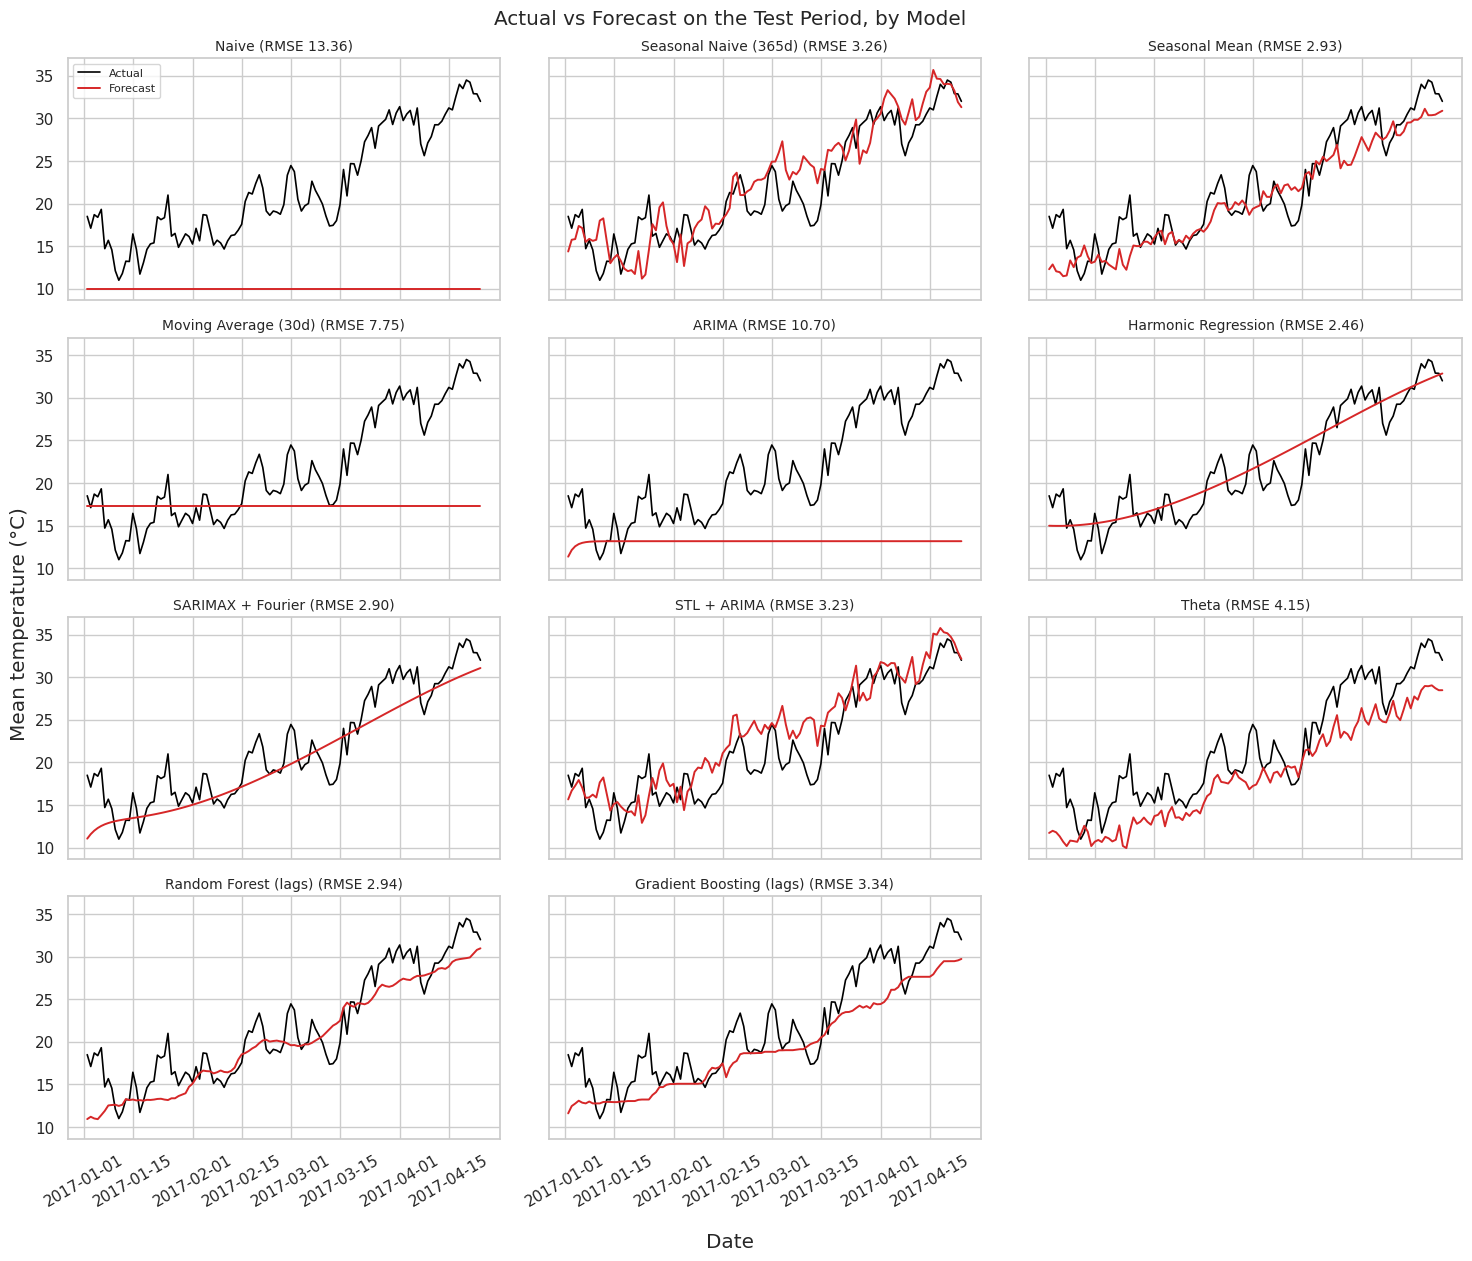

In [32]:
def plot_model_grid(test_data, forecasts, scores, n_columns=3, filename=None):
    """One panel per model: actual test values versus that model's forecast."""
    n_models = len(forecasts)
    n_rows = int(np.ceil(n_models / n_columns))
    fig, axes = plt.subplots(n_rows, n_columns, figsize=(15, 3.2 * n_rows), sharex=True, sharey=True)
    axes = np.atleast_1d(axes).ravel()

    for ax, (name, frame) in zip(axes, forecasts.items()):
        ax.plot(test_data, color="black", linewidth=1.2, label="Actual")
        ax.plot(frame["forecast"], color="tab:red", linewidth=1.4, label="Forecast")
        ax.set_title(f"{name} (RMSE {scores.loc[name, 'RMSE']:.2f})", fontsize=10)
        ax.tick_params(axis="x", rotation=30)
    for ax in axes[n_models:]:
        ax.set_visible(False)

    axes[0].legend(loc="best", fontsize=8)
    fig.supxlabel("Date")
    fig.supylabel("Mean temperature (°C)")
    fig.suptitle("Actual vs Forecast on the Test Period, by Model")
    finish_plot(filename)


plot_model_grid(test, test_forecasts, results, filename="14_model_grid")

Three lowest-RMSE models: ['Harmonic Regression', 'SARIMAX + Fourier', 'Seasonal Mean']


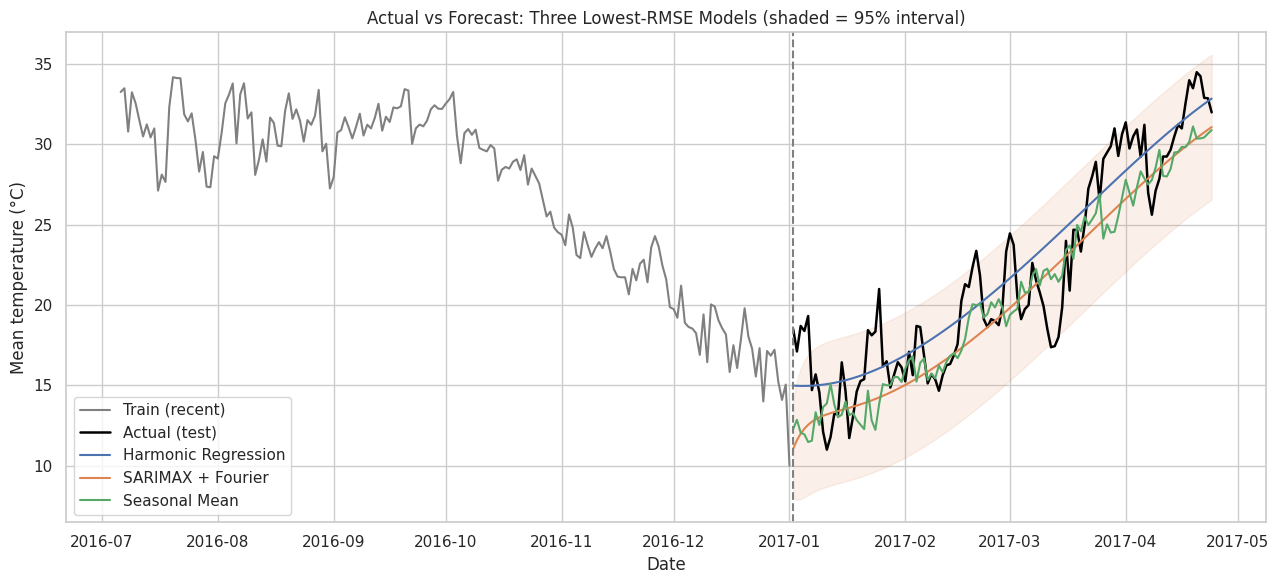

In [33]:
def plot_forecast_comparison(train_data, test_data, forecasts, model_names,
                             history_days=180, filename=None):
    """Plot recent training data, actual test data and selected model forecasts."""
    fig, ax = plt.subplots(figsize=(13, 6))
    ax.plot(train_data.iloc[-history_days:], color="grey", label="Train (recent)")
    ax.plot(test_data, color="black", linewidth=1.8, label="Actual (test)")

    for name in model_names:
        frame = forecasts[name]
        line, = ax.plot(frame["forecast"], linewidth=1.5, label=name)
        if {"lower", "upper"}.issubset(frame.columns):
            ax.fill_between(frame.index, frame["lower"], frame["upper"],
                            color=line.get_color(), alpha=0.12)

    ax.axvline(test_data.index[0], color="grey", linestyle="--")
    ax.set_title("Actual vs Forecast: Three Lowest-RMSE Models (shaded = 95% interval)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Mean temperature (°C)")
    ax.legend()
    finish_plot(filename)


top_three_models = results["RMSE"].nsmallest(3).index.tolist()
print("Three lowest-RMSE models:", top_three_models)
plot_forecast_comparison(train, test, test_forecasts, top_three_models, filename="15_top_models")

### Interpretation

- **Flat-line models** cut straight through the rising seasonal curve and are right only where the actual values cross their level.
- **Seasonal models** follow the climb from winter to spring. Their remaining errors are mostly day-to-day weather deviations and any difference between this year's level and the historical average.
- **Machine-learning models with recursive forecasting** start from recent observations but, as the horizon grows, rely more on the seasonal features. Watch for stair-step or flattened shapes, typical of tree models.
- **Prediction intervals** (shaded) should contain most actual points. If many points lie outside, the model is overconfident.

## 18. Residual Analysis

**Concept:** A residual is `actual − forecast`. If a model has captured all the *predictable* structure, its residuals should look like random noise:

- centred around **zero** (no systematic bias),
- **constant spread** over time,
- roughly **bell-shaped**,
- **no autocorrelation**: no ACF spikes outside the confidence band.

**Why:** Remaining structure in the residuals means information is still unused. The assumptions behind prediction intervals also rely on these properties.

We analyse the residuals of the model with the **lowest test RMSE**. The Ljung-Box test formally checks for autocorrelation (H0: no autocorrelation up to the given lag).

> **Note:** these are *multi-step* forecast errors over a long horizon. Errors far ahead naturally share a common drift, so some autocorrelation is expected even from a reasonable model. A strict one-step-ahead check would re-forecast after each new observation (rolling-origin evaluation); see the README's future improvements.

Model with the lowest test RMSE: Harmonic Regression
Model with the lowest test MAE : Harmonic Regression


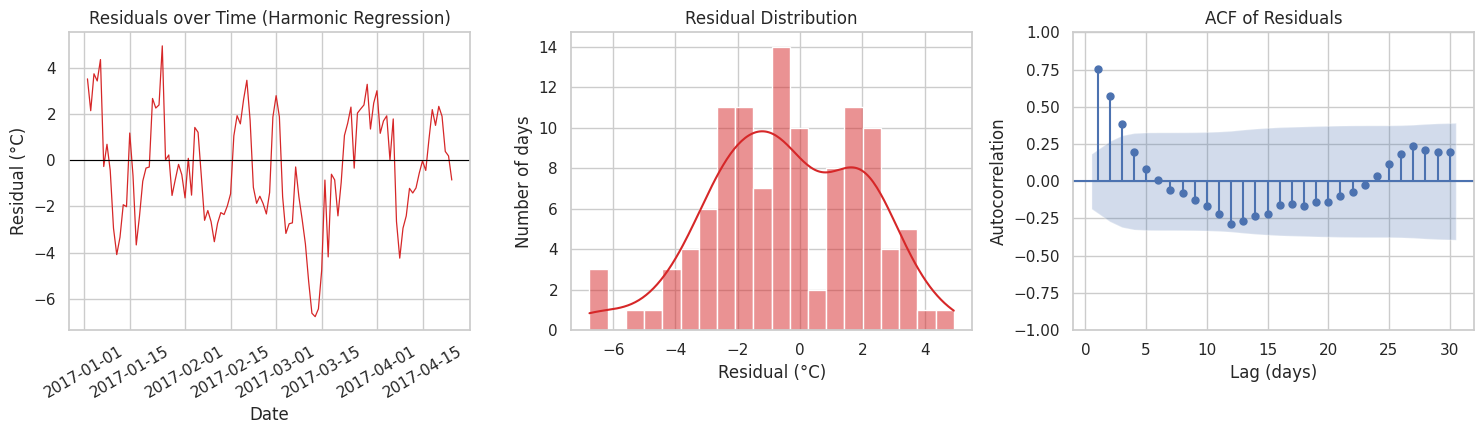

Mean residual (bias): -0.422 °C
Residual std        : 2.430 °C


,lb_stat,lb_pvalue
10,133.522269,8.918620e-24
20,188.634266,1.964142e-29


In [34]:
best_model_name = results["RMSE"].idxmin()
print(f"Model with the lowest test RMSE: {best_model_name}")
print(f"Model with the lowest test MAE : {results['MAE'].idxmin()}")

residuals = test - test_forecasts[best_model_name]["forecast"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].plot(residuals, color="tab:red", linewidth=0.9)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title(f"Residuals over Time ({best_model_name})")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Residual (°C)")
axes[0].tick_params(axis="x", rotation=30)

sns.histplot(residuals, bins=20, kde=True, color="tab:red", ax=axes[1])
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual (°C)")
axes[1].set_ylabel("Number of days")

plot_acf(residuals, lags=30, ax=axes[2], zero=False)
axes[2].set_title("ACF of Residuals")
axes[2].set_xlabel("Lag (days)")
axes[2].set_ylabel("Autocorrelation")
finish_plot("16_residual_analysis")

print(f"Mean residual (bias): {residuals.mean():.3f} °C")
print(f"Residual std        : {residuals.std():.3f} °C")
display(acorr_ljungbox(residuals, lags=[10, 20]))

### Interpretation

- **Mean residual:** the average bias. Close to zero means no systematic over- or under-prediction. A clearly positive or negative value means the forecast is consistently too cold or too warm for this window.
- **Residuals over time:** look for long runs above or below zero. Runs mean the forecast drifts away from reality for weeks at a time (for example a warm spell the model could not know about).
- **Distribution:** a roughly symmetric bell shape supports the normality assumption behind prediction intervals. With only about 113 points the histogram is rough.
- **ACF and Ljung-Box:** a small p-value (`lb_pvalue < 0.05`) means the residuals still contain temporal structure. For multi-month forecasts this is common, because errors persist (a warm anomaly lasts several days).

## 19. Future Forecast

**Model selection rule (documented before use):** the final model is the one with the **lowest test RMSE** in section 16. RMSE is preferred because large forecast errors are the most costly for planning. The code also prints the MAE winner so that we can see whether both metrics agree.

> **Honest caveat:** the test set is now used both to compare models and to choose one, and it is short and seasonally limited. The choice is therefore reasonable but not guaranteed to be the best model across all seasons.

**Horizon:** the test file ends in April 2017 and the data is daily, so we forecast the **next 90 days**, about one season. Forecasts beyond that would extrapolate too far for a model trained on roughly four years of data.

The chosen model is **re-fitted on the entire dataset** (train + test) so that it uses all available information, then forecasts dates it has never seen.

Selected model (lowest test RMSE): Harmonic Regression
Lowest MAE                        : Harmonic Regression


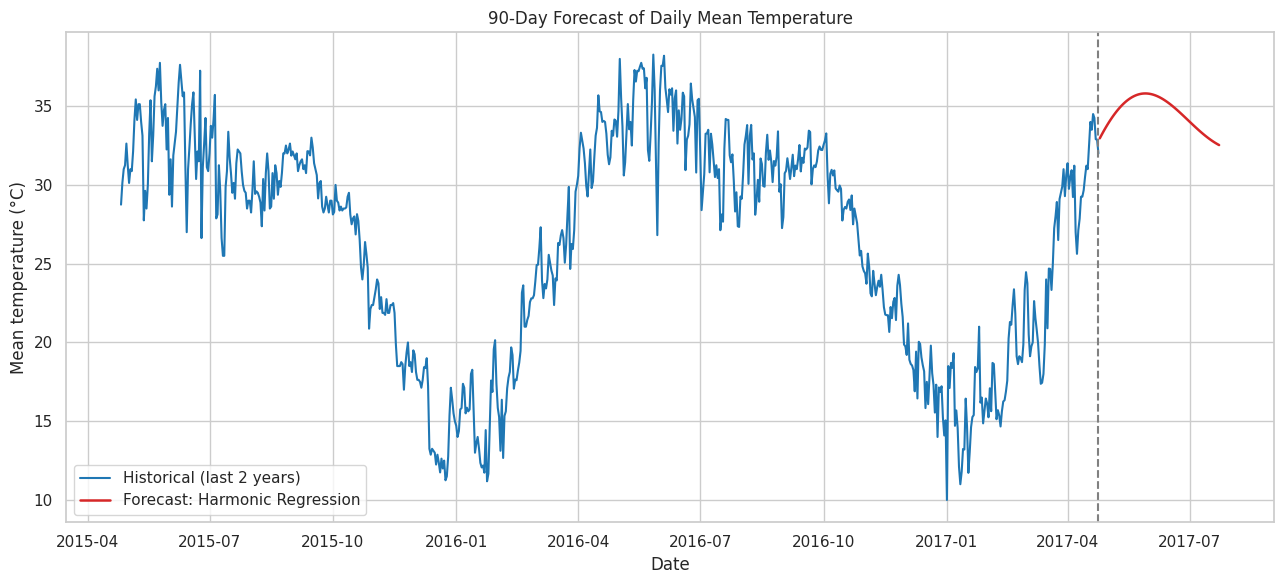

,forecast
2017-04-25,32.96
2017-04-26,33.12
2017-04-27,33.28
2017-04-28,33.43
2017-04-29,33.58
2017-04-30,33.72
2017-05-01,33.86
2017-05-02,34.00
2017-05-03,34.13
2017-05-04,34.26


In [35]:
FORECAST_HORIZON_DAYS = 90

selected_model_name = results["RMSE"].idxmin()
print(f"Selected model (lowest test RMSE): {selected_model_name}")
print(f"Lowest MAE                        : {results['MAE'].idxmin()}")

future_index = pd.date_range(
    start=full_series.index[-1] + pd.Timedelta(days=1), periods=FORECAST_HORIZON_DAYS, freq="D"
)
future_forecast = MODEL_FORECASTERS[selected_model_name](full_series, future_index)

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(full_series.iloc[-730:], color="tab:blue", label="Historical (last 2 years)")
ax.plot(future_forecast["forecast"], color="tab:red", linewidth=1.8,
        label=f"Forecast: {selected_model_name}")
if {"lower", "upper"}.issubset(future_forecast.columns):
    ax.fill_between(future_forecast.index, future_forecast["lower"], future_forecast["upper"],
                    color="tab:red", alpha=0.2, label="95% prediction interval")
ax.axvline(full_series.index[-1], color="grey", linestyle="--")
ax.set_title(f"{FORECAST_HORIZON_DAYS}-Day Forecast of Daily Mean Temperature")
ax.set_xlabel("Date")
ax.set_ylabel("Mean temperature (°C)")
ax.legend()
finish_plot("17_future_forecast")

display(future_forecast.round(2).head(10))

### Interpretation

- The forecast continues from the end of the test file (late April) into the hottest part of the year. Values close to the forecast start are anchored to recent observations; the further ahead, the more the forecast follows the seasonal shape.
- The **prediction interval** (shown only if the selected model provides one) is the range in which about 95% of future daily values are expected to fall *if the model assumptions hold*. It is wide because daily weather is noisy.
- **Forecasts are estimates, not certainties.** Unusual weather, changes in the measurement process or long-term climate shifts can push real values outside the interval.
- This forecast reaches into the pre-monsoon and monsoon months, which were **not part of the test window**. The test results say little about how well a model handles that part of the year, so the forecast deserves extra caution.

## 20. Business / Practical Interpretation

A temperature forecast with an uncertainty range could support decisions such as:

- **Energy demand planning:** cooling and heating loads are temperature-driven; a seasonal temperature outlook helps utilities anticipate high-demand periods. *(This dataset contains no electricity data, so the size of the effect would have to be estimated separately.)*
- **Public health preparation:** heat-related risks rise in hot periods; a seasonal outlook can inform advance planning of awareness campaigns and resources.
- **Agriculture and outdoor operations:** planning irrigation, crop scheduling, events and construction around expected warm/cool periods.

**What these models cannot do:** they are *univariate* (the machine-learning models add only lags and calendar terms). They predict the typical seasonal temperature and cannot anticipate specific weather events (heat waves, western disturbances, monsoon onset timing) weeks in advance. They suit *seasonal outlook and planning*, not replacing a meteorological forecast.

## 21. Key Findings

The summary below is generated from the results of this run, so the numbers always match the notebook.

In [36]:
print("KEY FINDINGS")
print("=" * 60)

print(f"Training data : {len(train)} days ({train.index[0].date()} to {train.index[-1].date()})")
print(f"Test data     : {len(test)} days ({test.index[0].date()} to {test.index[-1].date()})")

print("\nTrend")
print(f"  Yearly means (complete training years): "
      f"{', '.join(f'{year}: {value:.1f} °C' for year, value in yearly_mean.items())}")
print(f"  Trend strength (decomposition): {trend_strength:.2f}")

print("\nSeasonality")
print(f"  Warmest month on average: month {monthly_climatology.idxmax()} "
      f"({monthly_climatology.max():.1f} °C)")
print(f"  Coldest month on average: month {monthly_climatology.idxmin()} "
      f"({monthly_climatology.min():.1f} °C)")
print(f"  Seasonal strength (decomposition): {seasonal_strength:.2f}")

print("\nStationarity")
print(f"  ADF p-value (original)    : {adf_p_original:.4f}")
print(f"  ADF p-value (differenced) : {adf_p_diff:.4f}")
print(f"  Differencing order used   : d = {d_order}")

print("\nModel performance (test file), sorted by RMSE")
display(results.sort_values("RMSE").round(3))
print(f"Selected model (lowest RMSE): {selected_model_name}")
print(f"Naive baseline RMSE: {results.loc['Naive', 'RMSE']:.3f}")

print("\nResiduals")
print(f"  Mean bias of the selected model: {residuals.mean():.3f} °C")

KEY FINDINGS
Training data : 1462 days (2013-01-01 to 2017-01-01)
Test data     : 113 days (2017-01-02 to 2017-04-24)

Trend
  Yearly means (complete training years): 2013: 24.8 °C, 2014: 25.0 °C, 2015: 25.1 °C, 2016: 27.1 °C
  Trend strength (decomposition): 0.17

Seasonality
  Warmest month on average: month 6 (33.7 °C)
  Coldest month on average: month 1 (13.3 °C)
  Seasonal strength (decomposition): 0.94

Stationarity
  ADF p-value (original)    : 0.2774
  ADF p-value (differenced) : 0.0000
  Differencing order used   : d = 1

Model performance (test file), sorted by RMSE


,MAE,RMSE,MAPE (%)
Model,,,
Harmonic Regression,2.028,2.456,10.439
SARIMAX + Fourier,2.302,2.904,10.823
Seasonal Mean,2.303,2.930,10.900
Random Forest (lags),2.318,2.942,11.006
STL + ARIMA,2.596,3.233,13.856
Seasonal Naive (365d),2.621,3.259,13.643
Gradient Boosting (lags),2.676,3.344,11.910
Theta,3.547,4.153,16.546
Moving Average (30d),5.830,7.753,23.524


Selected model (lowest RMSE): Harmonic Regression
Naive baseline RMSE: 13.362

Residuals
  Mean bias of the selected model: -0.422 °C


### Summary

- **Trend:** long-term change over four years is small relative to the seasonal swing.
- **Seasonality:** the dominant structure is a strong **yearly cycle**; there is no meaningful weekly pattern.
- **Stationarity:** see the ADF results above. The mean follows the season, so a model must handle seasonality explicitly, regardless of the exact p-value.
- **Models:** models with no seasonal component cannot follow the seasonal climb; models with seasonal information do better. The comparison table gives exact errors, and the short test window means small differences should not be over-interpreted.
- **Forecast behaviour:** the 90-day forecast continues the seasonal pattern with an uncertainty band that reflects day-to-day weather noise (for models that provide one).
- **Limits:** see the next section.

## 22. Limitations

- **Short test window:** only about 113 days (winter to early summer). The model ranking does not cover the monsoon or peak summer, and small differences between models are not reliable.
- **Test set used twice:** it is used to compare models and to select one. A cleaner design would add a separate validation period, or use rolling-origin cross-validation on the training data.
- **Short history:** only about four years of training data, so the seasonal shape is estimated from four repetitions. Unusual years have a large influence.
- **Univariate models:** humidity, wind, pressure, rainfall and large-scale climate drivers are not used. Their future values are unknown anyway, so they would themselves need forecasting.
- **Untuned machine-learning models:** hyperparameters were fixed, not tuned, and recursive forecasting accumulates errors over long horizons.
- **Constant variance assumption:** the intervals assume similar residual variance throughout the year; the rolling standard deviation suggested this is only approximately true.
- **Structural change and extreme events:** heat waves, monsoon shifts and climate change can move real temperatures outside the historical pattern.
- **Data quality:** the data comes from a third-party API, and abnormal values were found in other columns. Licence and provenance should be checked before any commercial use.

## 23. Conclusion

This project applied a complete time-series workflow to Delhi's daily mean temperature. The two provided files were cleaned and checked for overlap and gaps; the training file was explored with rolling statistics, resampling and calendar patterns, decomposed into trend, seasonality and residual, tested for stationarity, and analysed with ACF and PACF. Eleven models, from simple baselines to ARIMA, STL, Theta and machine-learning approaches, were fitted on the training file and compared on the chronological test file. The final model was chosen with a rule stated in advance, its residuals were checked, and it produced a 90-day forecast with uncertainty where available.

The main lesson is that **understanding the structure of the data comes before modelling**: the strong yearly cycle explains why non-seasonal models struggle over long horizons. A second lesson is that **honest evaluation matters more than model count**: chronological splits, no leakage, meaningful baselines, and awareness that a short test window limits what the results can prove.

**Next steps** are listed in the README: rolling-origin cross-validation, tuned machine-learning models, exogenous variables, and comparison with ETS and Prophet.